### Step 1: Import libraries and load datasets

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for consistent visualizations later
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Load the datasets
batting_df = pd.read_csv("/content/batting_summary.csv")
bowling_df = pd.read_csv("/content/bowling_summary.csv")
matches_df = pd.read_csv("/content/match_schedule_results.csv")
print(f"DEBUG (Load): matches_df shape immediately after pd.read_csv: {matches_df.shape}") # New debug line
players_df = pd.read_csv("/content/world_cup_players_info.csv")

print("Datasets loaded successfully.")

# Display the first few rows and shape of each DataFrame to inspect
print("\nBatting Summary (first 5 rows and shape):")
display(batting_df.head())
print(f"Shape: {batting_df.shape}")

print("\nBowling Summary (first 5 rows and shape):")
display(bowling_df.head())
print(f"Shape: {bowling_df.shape}")

print("\nMatch Schedule Results (first 5 rows and shape):")
display(matches_df.head())
print(f"Shape: {matches_df.shape}")

print("\nWorld Cup Players Info (first 5 rows and shape):")
display(players_df.head())
print(f"Shape: {players_df.shape}")

DEBUG (Load): matches_df shape immediately after pd.read_csv: (48, 7)
Datasets loaded successfully.

Batting Summary (first 5 rows and shape):


,Match_no,Match_Between,Team_Innings,Batsman_Name,Batting_Position,Dismissal,Runs,Balls,4s,6s,Strike_Rate
0,1,England vs New Zealand,England,Jonny Bairstow,1,c Daryl Mitchell b Mitchell Santner,33,35,4,1,94.300
1,1,England vs New Zealand,England,Dawid Malan,2,c Tom Latham b Matt Henry,14,24,2,0,58.300
2,1,England vs New Zealand,England,Joe Root,3,b Glenn Phillips,77,86,4,1,89.500
3,1,England vs New Zealand,England,Harry Brook,4,c Devon Conway b Rachin Ravindra,25,16,4,1,156.300
4,1,England vs New Zealand,England,Moeen Ali,5,b Glenn Phillips,11,17,1,0,64.700


Shape: (916, 11)

Bowling Summary (first 5 rows and shape):


,Match_no,Match_Between,Bowling_Team,Bowler_Name,Overs,Maidens,Runs,Wickets,Economy
0,1,England vs New Zealand,New Zealand,Trent Boult,10.0,1,48,1,4.8
1,1,England vs New Zealand,New Zealand,Matt Henry,10.0,1,48,3,4.8
2,1,England vs New Zealand,New Zealand,Mitchell Santner,10.0,0,37,2,3.7
3,1,England vs New Zealand,New Zealand,Jimmy Neesham,7.0,0,56,0,8.0
4,1,England vs New Zealand,New Zealand,Rachin Ravindra,10.0,0,76,1,7.6


Shape: (574, 9)

Match Schedule Results (first 5 rows and shape):


,Match_no,Date,Venue,Team1,Team2,Winner,Scorecard URL
0,1,October 5,Ahmedabad,England,New Zealand,New Zealand,https://www.cricketwa.com/scorecard/18020/engl...
1,2,October 6,Hyderabad,Pakistan,Netherlands,Pakistan,https://www.cricketwa.com/scorecard/18021/paki...
2,3,October 7,Dharamsala,Bangladesh,Afghanistan,Bangladesh,https://www.cricketwa.com/scorecard/23008/bang...
3,4,October 7,Delhi,South Africa,Sri Lanka,South Africa,https://www.cricketwa.com/scorecard/23009/sout...
4,5,October 8,Chennai,India,Australia,India,https://www.cricketwa.com/scorecard/23010/indi...


Shape: (48, 7)

World Cup Players Info (first 5 rows and shape):


,player_name,team_name,image_of_player,battingStyle,bowlingStyle,playingRole,description
0,Jonny Bairstow,England,,Right-hand bat,Right-arm fast-medium,Wicketkeeper Batter,Jonny Bairstow is an English cricketer known f...
1,Joe Root,England,,Right hand Bat,Right arm Offbreak,Top order Batter,Joe Root is an English cricketer known for his...
2,Jos Buttler,England,,Right hand Bat,,Wicketkeeper Batter,Jos Buttler is an English cricketer known for ...
3,Will Young,New Zealand,,Right hand Bat,Right arm Offbreak,Top order Batter,Will Young is a New Zealand cricketer known fo...
4,Rachin Ravindra,New Zealand,,Left hand Bat,Slow Left arm Orthodox,Top order Batter,Rachin Ravindra is a New Zealand cricketer kno...


Shape: (151, 7)


### Step 2: Quick cleaning

In [99]:
# Function to strip spaces from text columns
def strip_whitespace_from_df(df):
    for col in df.select_dtypes(include=['object', 'string']).columns:
        df[col] = df[col].astype(str).str.strip()
    return df

# Function to clean and standardize team names
def standardize_team_names(df, column_names):
    team_name_mapping = {
        'Afghanistan': 'Afghanistan',
        'Australia': 'Australia',
        '"Bangladesh"': 'Bangladesh', # Handle cases where quotes might be present
        'Bangladesh': 'Bangladesh',
        'England': 'England',
        'India': 'India',
        'Netherlands': 'Netherlands',
        'New Zealand': 'New Zealand',
        'Pakistan': 'Pakistan',
        'South Africa': 'South Africa',
        'Sri Lanka': 'Sri Lanka',
        # Add any other variations found in the data
        'AFG': 'Afghanistan',
        'AUS': 'Australia',
        'BAN': 'Bangladesh',
        'ENG': 'England',
        'IND': 'India',
        'NED': 'Netherlands',
        'NZ': 'New Zealand',
        'PAK': 'Pakistan',
        'SA': 'South Africa',
        'SL': 'Sri Lanka',
        'United States': 'USA' # Example, if this variation existed
    }
    for col in column_names:
        if col in df.columns:
            df[col] = df[col].replace(team_name_mapping)
    return df

print("Cleaning functions defined.")

Cleaning functions defined.


In [124]:
# TEMPORARY FIX: Reload dataframes to circumvent kernel state issue
batting_df = pd.read_csv("/content/batting_summary.csv")
bowling_df = pd.read_csv("/content/bowling_summary.csv")
matches_df = pd.read_csv("/content/match_schedule_results.csv")
players_df = pd.read_csv("/content/world_cup_players_info.csv")
print(f"DEBUG: matches_df shape immediately after re-loading in cleaning cell: {matches_df.shape}")

# Apply stripping whitespace
batting_df = strip_whitespace_from_df(batting_df)
bowling_df = strip_whitespace_from_df(bowling_df)
matches_df = strip_whitespace_from_df(matches_df)
players_df = strip_whitespace_from_df(players_df)
print(f"DEBUG: matches_df shape after strip_whitespace_from_df: {matches_df.shape}")

# Standardize team names across all relevant columns
batting_df = standardize_team_names(batting_df, ['Team_Innings'])
bowling_df = standardize_team_names(bowling_df, ['Bowling_Team'])
matches_df = standardize_team_names(matches_df, ['Team1', 'Team2', 'Winner']) # Corrected Team1 and Team2
players_df = standardize_team_names(players_df, ['team_name'])
print(f"DEBUG: matches_df shape after standardize_team_names: {matches_df.shape}")

# DIAGNOSTIC: 'Date' column sample (original string type) before split
print(f"\nDIAGNOSTIC: 'Date' column sample (original string type, before split):\n{matches_df['Date'].head()}")

# Convert Date in matches_df to datetime
# Pre-process the Date string to remove time and timezone for robust parsing
matches_df['Date_str_cleaned'] = matches_df['Date'].astype(str).str.split(' - ').str[0].str.strip() # Added .str.strip()
matches_df['Date_str_cleaned'] = matches_df['Date_str_cleaned'] + ', 2023' # Append year
print(f"\nDIAGNOSTIC: 'Date' column sample after split, strip, and year added (string type):\n{matches_df['Date_str_cleaned'].head()}")

# Convert using pd.to_datetime (allowing inference, now with year)
matches_df['Date'] = pd.to_datetime(matches_df['Date_str_cleaned'], errors='coerce')
matches_df.drop(columns=['Date_str_cleaned'], inplace=True, errors='ignore') # Drop temporary column
print(f"DEBUG: matches_df shape after pd.to_datetime (before dropna): {matches_df.shape}")

# --- DIAGNOSTIC: Check Date column immediately after conversion ---
print(f"\nNumber of NaT values in matches_df['Date'] after conversion: {matches_df['Date'].isnull().sum()}")
print(f"Sample of matches_df['Date'] after conversion:\n{matches_df['Date'].head()}")
print(f"Dtype of matches_df['Date'] after conversion: {matches_df['Date'].dtype}")
# -------------------------------------------------------------------

# Convert important numeric columns to proper numeric type
# Batting_df
numeric_cols_batting = ['Runs', 'Balls', '4s', '6s', 'Strike_Rate']
for col in numeric_cols_batting:
    # Using fillna(0) after to_numeric, assuming 0 is a reasonable default for missing numerical stats
    batting_df[col] = pd.to_numeric(batting_df[col], errors='coerce').fillna(0)

# Bowling_df
numeric_cols_bowling = ['Overs', 'Maidens', 'Runs', 'Wickets', 'Economy'] # Corrected 'Runs_conceded' to 'Runs'
for col in numeric_cols_bowling:
    bowling_df[col] = pd.to_numeric(bowling_df[col], errors='coerce').fillna(0)

# Remove duplicates
batting_df.drop_duplicates(inplace=True)
bowling_df.drop_duplicates(inplace=True)
matches_df.drop_duplicates(inplace=True)
players_df.drop_duplicates(inplace=True)
print(f"DEBUG: matches_df shape after drop_duplicates: {matches_df.shape}")

# Handle basic missing values
# For batting and bowling, 0 for runs/wickets/etc. is often appropriate for NaN
batting_df.fillna({'Batsman_Name': 'Unknown', 'Team_Innings': 'Unknown', 'Dismissal': 'Unknown', 'Batting_Position': 0}, inplace=True)
bowling_df.fillna({'Bowler_Name': 'Unknown', 'Bowling_Team': 'Unknown'}, inplace=True)

# For matches, fill missing categorical with 'No Result' or 'Unknown'
matches_df.fillna({'Winner': 'No Result', 'Venue': 'Unknown'}, inplace=True)
# If Date is NaT after coercion, consider dropping or handling specifically based on impact
# For this analysis, we'll drop rows with missing Date as it's critical for match identification.
matches_df.dropna(subset=['Date'], inplace=True)
print(f"DEBUG: matches_df shape after dropna(subset=['Date']): {matches_df.shape}")

# For players_df, fill missing categorical with 'Unknown' (using correct column names)
players_df.fillna({'playingRole': 'Unknown', 'battingStyle': 'Unknown', 'bowlingStyle': 'Unknown'}, inplace=True)

print("\nData cleaning and standardization complete.")

# Display info and describe to confirm cleaning
print("\nBatting DF Info after cleaning:")
batting_df.info()
print("\nBowling DF Info after cleaning:")
bowling_df.info()
print("\nMatches DF Info after cleaning:")
matches_df.info()
print("\nPlayers DF Info after cleaning:")
players_df.info()

DEBUG: matches_df shape immediately after re-loading in cleaning cell: (48, 7)
DEBUG: matches_df shape after strip_whitespace_from_df: (48, 7)
DEBUG: matches_df shape after standardize_team_names: (48, 7)

DIAGNOSTIC: 'Date' column sample (original string type, before split):
0    October 5
1    October 6
2    October 7
3    October 7
4    October 8
Name: Date, dtype: object

DIAGNOSTIC: 'Date' column sample after split, strip, and year added (string type):
0    October 5, 2023
1    October 6, 2023
2    October 7, 2023
3    October 7, 2023
4    October 8, 2023
Name: Date_str_cleaned, dtype: object
DEBUG: matches_df shape after pd.to_datetime (before dropna): (48, 7)

Number of NaT values in matches_df['Date'] after conversion: 0
Sample of matches_df['Date'] after conversion:
0   2023-10-05
1   2023-10-06
2   2023-10-07
3   2023-10-07
4   2023-10-08
Name: Date, dtype: datetime64[ns]
Dtype of matches_df['Date'] after conversion: datetime64[ns]
DEBUG: matches_df shape after drop_duplicate

### Step 3: Top performers in each match

In [117]:
# 1. Best scorer in each match
# For each Match_no in batting_df, find the player with highest Runs
best_scorers_per_match = batting_df.loc[batting_df.groupby('Match_no')['Runs'].idxmax()]

# 2. Best bowler in each match
# For each Match_no in bowling_df, find the player with highest Wickets
# If there is a tie, choose the player with fewer Runs conceded (already named 'Runs' in bowling_df) or better Economy
best_bowlers_per_match = bowling_df.loc[bowling_df.groupby('Match_no').apply(lambda x: x.sort_values(by=['Wickets', 'Runs'], ascending=[False, True]).iloc[0]).index]

print("Top scorers per match:")
display(best_scorers_per_match.head())
print("Top bowlers per match:")
display(best_bowlers_per_match.head())

Top scorers per match:


/tmp/ipykernel_453/2068677086.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  best_bowlers_per_match = bowling_df.loc[bowling_df.groupby('Match_no').apply(lambda x: x.sort_values(by=['Wickets', 'Runs'], ascending=[False, True]).iloc[0]).index]


,Match_no,Match_Between,Team_Innings,Batsman_Name,Batting_Position,Dismissal,Runs,Balls,4s,6s,Strike_Rate
11,1,England vs New Zealand,New Zealand,Devon Conway,1,not out,152,121,19,3,125.6
17,2,Pakistan vs Netherlands,Pakistan,Mohammad Rizwan,4,b Bas de Leede,68,75,8,0,90.7
50,3,Afghanistan vs Bangladesh,Bangladesh,Najmul Hossain Shanto,4,not out,59,83,3,1,71.1
55,4,South Africa vs Sri Lanka,South Africa,Rassie van der Dussen,3,c Sadeera Samarawickrama b Dunith Wellalage,108,110,13,2,98.2
86,5,Australia vs India,India,KL Rahul,5,not out,97,115,8,2,84.3


Top bowlers per match:


,Match_no,Match_Between,Bowling_Team,Bowler_Name,Overs,Maidens,Runs,Wickets,Economy
Match_no,,,,,,,,,
1,1,England vs New Zealand,New Zealand,Matt Henry,10.0,1,48,3,4.80
2,1,England vs New Zealand,New Zealand,Mitchell Santner,10.0,0,37,2,3.70
3,1,England vs New Zealand,New Zealand,Jimmy Neesham,7.0,0,56,0,8.00
4,1,England vs New Zealand,New Zealand,Rachin Ravindra,10.0,0,76,1,7.60
5,1,England vs New Zealand,New Zealand,Glenn Phillips,3.0,0,17,2,5.67


In [118]:
# Calculate which player was top scorer in a match the most times
most_frequent_top_scorer = best_scorers_per_match['Batsman_Name'].value_counts().reset_index()
most_frequent_top_scorer.columns = ['Player_Name', 'Count_Top_Scorer']

# Calculate which player was best bowler in a match the most times
most_frequent_best_bowler = best_bowlers_per_match['Bowler_Name'].value_counts().reset_index()
most_frequent_best_bowler.columns = ['Player_Name', 'Count_Best_Bowler']

print("Most frequent top scorers:")
display(most_frequent_top_scorer.head())
print("Most frequent best bowlers:")
display(most_frequent_best_bowler.head())

Most frequent top scorers:


,Player_Name,Count_Top_Scorer
0,Rohit Sharma,3
1,Daryl Mitchell,3
2,Quinton de Kock,3
3,Ben Stokes,2
4,Mohammad Rizwan,2


Most frequent best bowlers:


,Player_Name,Count_Best_Bowler
0,Matt Henry,1
1,Mitchell Santner,1
2,Jimmy Neesham,1
3,Rachin Ravindra,1
4,Glenn Phillips,1


/tmp/ipykernel_453/2770586376.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count_Top_Scorer', y='Player_Name', data=most_frequent_top_scorer.head(10), palette='viridis')


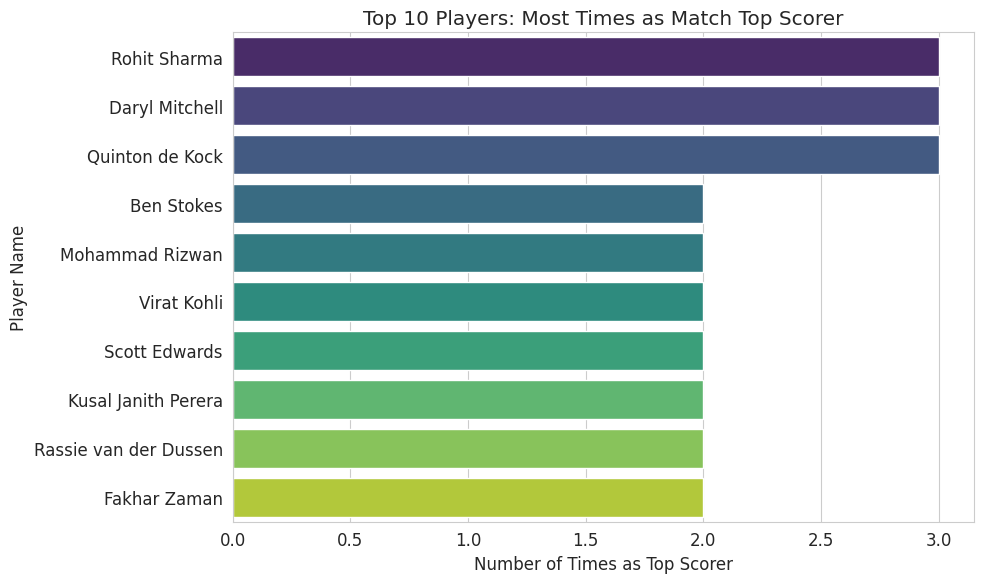

/tmp/ipykernel_453/2770586376.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count_Best_Bowler', y='Player_Name', data=most_frequent_best_bowler.head(10), palette='mako')


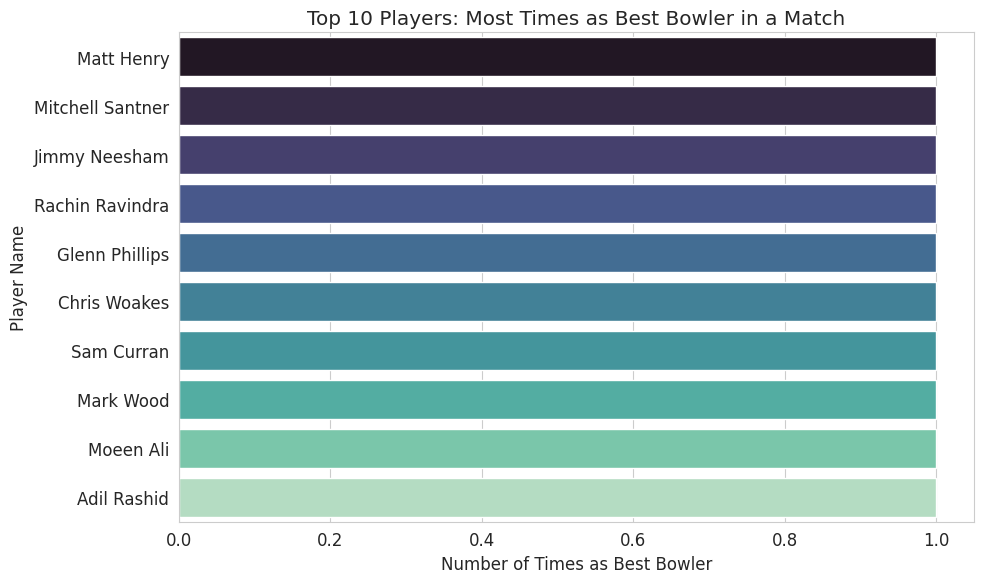

In [119]:
# Create 2 simple charts:

# Chart 1: Top players who were match top scorer most often
plt.figure(figsize=(10, 6))
sns.barplot(x='Count_Top_Scorer', y='Player_Name', data=most_frequent_top_scorer.head(10), palette='viridis')
plt.title('Top 10 Players: Most Times as Match Top Scorer')
plt.xlabel('Number of Times as Top Scorer')
plt.ylabel('Player Name')
plt.tight_layout()
plt.show()

# Chart 2: Top players who were best bowler most often
plt.figure(figsize=(10, 6))
sns.barplot(x='Count_Best_Bowler', y='Player_Name', data=most_frequent_best_bowler.head(10), palette='mako')
plt.title('Top 10 Players: Most Times as Best Bowler in a Match')
plt.xlabel('Number of Times as Best Bowler')
plt.ylabel('Player Name')
plt.tight_layout()
plt.show()

In [120]:
# Highlight these final insights clearly in text output

print("--- Main Insight 1: Top Performers in Each Match ---")

if not most_frequent_top_scorer.empty:
    top_scorer_most_times = most_frequent_top_scorer.iloc[0]
    print(f"\nMost frequent best scorer in a match: {top_scorer_most_times['Player_Name']} (achieved {int(top_scorer_most_times['Count_Top_Scorer'])} times)")
else:
    print("\nCould not determine most frequent best scorer.")

if not most_frequent_best_bowler.empty:
    best_bowler_most_times = most_frequent_best_bowler.iloc[0]
    print(f"Most frequent best bowler in a match: {best_bowler_most_times['Player_Name']} (achieved {int(best_bowler_most_times['Count_Best_Bowler'])} times)")
else:
    print("Could not determine most frequent best bowler.")

--- Main Insight 1: Top Performers in Each Match ---

Most frequent best scorer in a match: Rohit Sharma (achieved 3 times)
Most frequent best bowler in a match: Matt Henry (achieved 1 times)


### Step 4: Tournament best batsmen and bowlers

In [101]:
#### Batting Insights

# Group by player to get overall tournament batting stats
tournament_batting_stats = batting_df.groupby('Batsman_Name').agg(
    Total_Runs=('Runs', 'sum'),
    Total_Balls=('Balls', 'sum'),
    Centuries=('Runs', lambda x: (x >= 100).sum()),
    Fifties=('Runs', lambda x: ((x >= 50) & (x < 100)).sum()),
    Highest_Score=('Runs', 'max'),
    **{'6s': ('6s', 'sum')} # Corrected: using dictionary unpacking for non-identifier key
).reset_index()

# Calculate Strike Rate (Runs per 100 Balls)
tournament_batting_stats['Strike_Rate'] = np.where(
    tournament_batting_stats['Total_Balls'] > 0, # Avoid division by zero
    (tournament_batting_stats['Total_Runs'] / tournament_batting_stats['Total_Balls']) * 100,
    0
)

# Top 10 run scorers
top_10_run_scorers = tournament_batting_stats.sort_values(by='Total_Runs', ascending=False).head(10)
print("\nTop 10 Run Scorers:")
display(top_10_run_scorers[['Batsman_Name', 'Total_Runs']])

# Highest individual score
highest_individual_score = tournament_batting_stats.sort_values(by='Highest_Score', ascending=False).iloc[0]
print(f"\nHighest individual score: {highest_individual_score['Highest_Score']} by {highest_individual_score['Batsman_Name']}")

# Most centuries
most_centuries = tournament_batting_stats.sort_values(by='Centuries', ascending=False).iloc[0]
print(f"Most centuries: {most_centuries['Centuries']} by {most_centuries['Batsman_Name']}")

# Most fifties
most_fifties = tournament_batting_stats.sort_values(by='Fifties', ascending=False).iloc[0]
print(f"Most fifties: {most_fifties['Fifties']} by {most_fifties['Batsman_Name']}")

# Best strike rate (minimum 100 balls faced)
best_strike_rate_batters = tournament_batting_stats[tournament_batting_stats['Total_Balls'] >= 100].sort_values(by='Strike_Rate', ascending=False).head(5)
print("\nBest Strike Rate (min 100 balls faced):")
display(best_strike_rate_batters[['Batsman_Name', 'Strike_Rate', 'Total_Runs', 'Total_Balls']])


Top 10 Run Scorers:


,Batsman_Name,Total_Runs
143,Virat Kohli,765
103,Quinton de Kock,706
113,Rohit Sharma,597
104,Rachin Ravindra,578
21,David Warner,577
18,Daryl Mitchell,552
125,Shreyas Iyer,530
108,Rassie van der Dussen,480
20,David Miller,474
4,Aiden Markram,472



Highest individual score: 201 by Glenn Maxwell
Most centuries: 5 by Quinton de Kock
Most fifties: 6 by Virat Kohli

Best Strike Rate (min 100 balls faced):


,Batsman_Name,Strike_Rate,Total_Runs,Total_Balls
34,Glenn Maxwell,140.277778,404,288
139,Travis Head,127.777778,391,306
43,Heinrich Klaasen,126.478873,449,355
113,Rohit Sharma,125.949367,597,474
31,Fakhar Zaman,122.905028,220,179


In [102]:
#### Bowling Insights

tournament_bowling_stats = bowling_df.groupby('Bowler_Name').agg(
    Total_Overs=('Overs', 'sum'),
    Total_Maidens=('Maidens', 'sum'), # Corrected column name to 'Maidens'
    Total_Runs_Conceded=('Runs', 'sum'), # Corrected column name to 'Runs'
    Total_Wickets=('Wickets', 'sum')
).reset_index()

# Calculate Economy (Runs per Over)
tournament_bowling_stats['Economy'] = np.where(
    tournament_bowling_stats['Total_Overs'] > 0,
    tournament_bowling_stats['Total_Runs_Conceded'] / tournament_bowling_stats['Total_Overs'],
    0
)

# Top 10 wicket takers
top_10_wicket_takers = tournament_bowling_stats.sort_values(by='Total_Wickets', ascending=False).head(10)
print("\nTop 10 Wicket Takers:")
display(top_10_wicket_takers[['Bowler_Name', 'Total_Wickets', 'Total_Runs_Conceded', 'Total_Overs']])

# Best economy bowlers (minimum 30 overs)
best_economy_bowlers = tournament_bowling_stats[tournament_bowling_stats['Total_Overs'] >= 30].sort_values(by='Economy', ascending=True).head(5)
print("\nBest Economy Bowlers (min 30 overs):")
display(best_economy_bowlers[['Bowler_Name', 'Economy', 'Total_Overs', 'Total_Runs_Conceded']])

# Most maidens
most_maidens = tournament_bowling_stats.sort_values(by='Total_Maidens', ascending=False).iloc[0]
print(f"\nMost maidens: {most_maidens['Total_Maidens']} by {most_maidens['Bowler_Name']}")

# Best bowling spell in a match (most wickets, then fewest runs conceded)
best_bowling_spell = bowling_df.sort_values(by=['Wickets', 'Runs'], ascending=[False, True]).iloc[0]
print(f"Best bowling spell in a match: {best_bowling_spell['Wickets']}/{best_bowling_spell['Runs']} by {best_bowling_spell['Bowler_Name']} (Match No. {best_bowling_spell['Match_no']})")


Top 10 Wicket Takers:


,Bowler_Name,Total_Wickets,Total_Runs_Conceded,Total_Overs
63,Mohammed Shami,24,257,48.5
0,Adam Zampa,23,515,96.0
18,Dilshan Madushanka,21,525,77.8
23,Gerald Coetzee,20,396,63.3
33,Jasprit Bumrah,20,373,91.5
86,Shaheen Afridi,18,481,81.0
50,Marco Jansen,17,450,68.6
36,Josh Hazlewood,16,449,93.1
58,Mitchell Starc,16,528,87.0
77,Ravindra Jadeja,16,398,92.9



Best Economy Bowlers (min 30 overs):


,Bowler_Name,Economy,Total_Overs,Total_Runs_Conceded
33,Jasprit Bumrah,4.076503,91.5,373
60,Mohammad Nabi,4.143556,61.3,254
39,Keshav Maharaj,4.157303,89.0,370
77,Ravindra Jadeja,4.284177,92.9,398
40,Kuldeep Yadav,4.458465,95.1,424



Most maidens: 9 by Jasprit Bumrah
Best bowling spell in a match: 7/57 by Mohammed Shami (Match No. 46)


/tmp/ipykernel_453/4146642207.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Runs', y='Batsman_Name', data=top_10_run_scorers, palette='coolwarm')


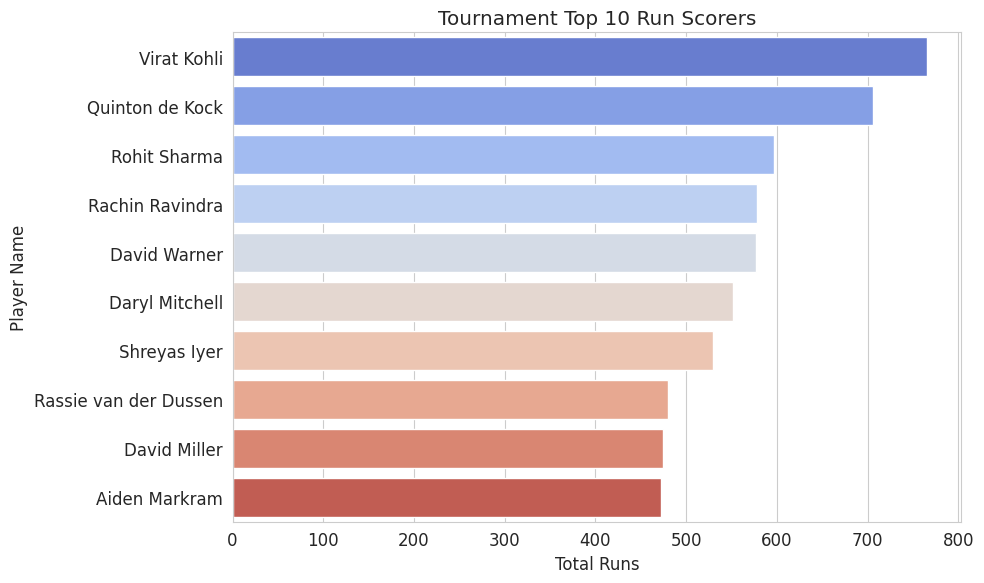

/tmp/ipykernel_453/4146642207.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Wickets', y='Bowler_Name', data=top_10_wicket_takers, palette='rocket')


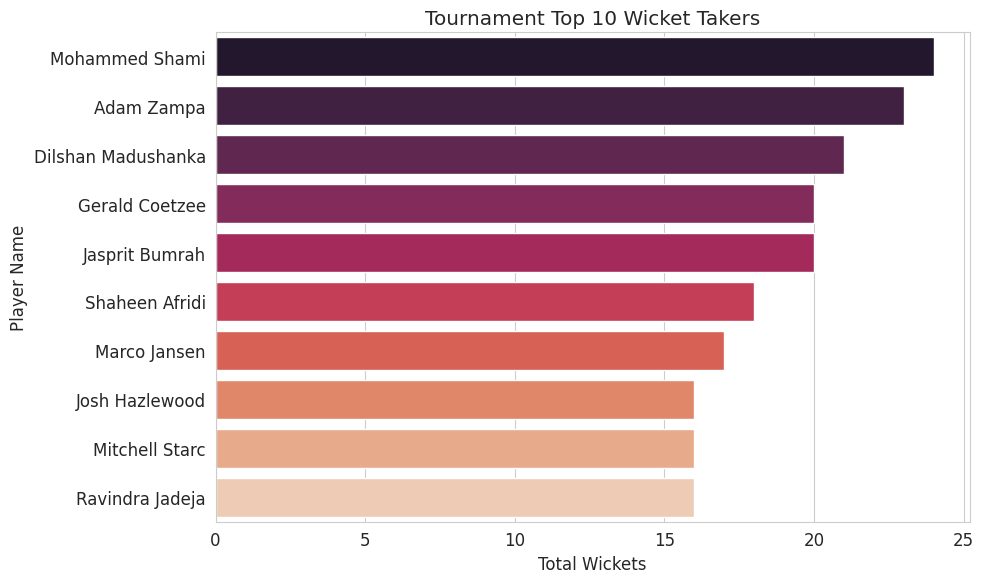

/tmp/ipykernel_453/4146642207.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Economy', y='Bowler_Name', data=best_economy_bowlers, palette='crest')


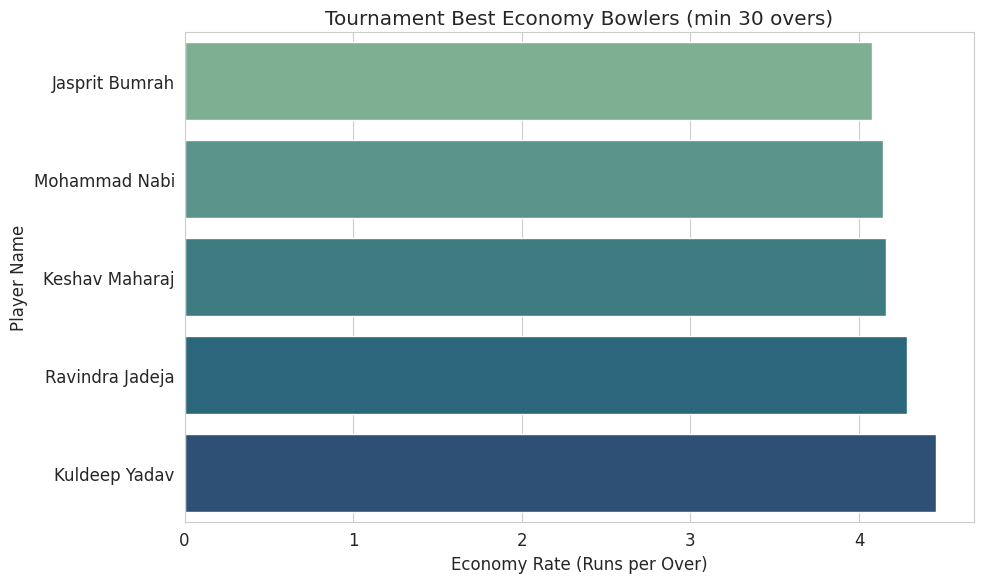

In [103]:
#### Visualizations for Tournament Best Performers

# Create simple charts:

# Chart 1: Top 10 run scorers
plt.figure(figsize=(10, 6))
sns.barplot(x='Total_Runs', y='Batsman_Name', data=top_10_run_scorers, palette='coolwarm')
plt.title('Tournament Top 10 Run Scorers')
plt.xlabel('Total Runs')
plt.ylabel('Player Name')
plt.tight_layout()
plt.show()

# Chart 2: Top 10 wicket takers
plt.figure(figsize=(10, 6))
sns.barplot(x='Total_Wickets', y='Bowler_Name', data=top_10_wicket_takers, palette='rocket')
plt.title('Tournament Top 10 Wicket Takers')
plt.xlabel('Total Wickets')
plt.ylabel('Player Name')
plt.tight_layout()
plt.show()

# Chart 3: Best economy bowlers
plt.figure(figsize=(10, 6))
sns.barplot(x='Economy', y='Bowler_Name', data=best_economy_bowlers, palette='crest')
plt.title('Tournament Best Economy Bowlers (min 30 overs)')
plt.xlabel('Economy Rate (Runs per Over)')
plt.ylabel('Player Name')
plt.tight_layout()
plt.show()

In [104]:
# Highlight final conclusions clearly:
print("--- Main Insight 2: Tournament Best Batsmen & Bowlers ---")

if not top_10_run_scorers.empty:
    best_batsman = top_10_run_scorers.iloc[0]
    print(f"\nBest batsman of tournament (most runs): {best_batsman['Batsman_Name']} with {int(best_batsman['Total_Runs'])} runs.")
else:
    print("\nCould not determine best batsman of the tournament.")

if not top_10_wicket_takers.empty:
    best_bowler = top_10_wicket_takers.iloc[0]
    print(f"Best bowler of tournament (most wickets): {best_bowler['Bowler_Name']} with {int(best_bowler['Total_Wickets'])} wickets.")
else:
    print("Could not determine best bowler of the tournament.")

--- Main Insight 2: Tournament Best Batsmen & Bowlers ---

Best batsman of tournament (most runs): Virat Kohli with 765 runs.
Best bowler of tournament (most wickets): Mohammed Shami with 24 wickets.


### Step 5: Team performance

In [125]:
#### Team-wise Match Outcomes

# Team-wise matches played
# Union Team1 and Team2 to get all teams that played matches, then count occurrences.
matches_played = pd.concat([matches_df['Team1'], matches_df['Team2']]).value_counts().reset_index()
matches_played.columns = ['Team', 'Matches_Played']

# Team-wise wins
teams_wins = matches_df['Winner'].value_counts().reset_index()
teams_wins.columns = ['Team', 'Wins']

# Merge to get a comprehensive team performance dataframe
team_performance = pd.merge(matches_played, teams_wins, on='Team', how='left').fillna(0)

# Team-wise losses
team_performance['Losses'] = team_performance['Matches_Played'] - team_performance['Wins']

# Win percentage
team_performance['Win_Percentage'] = np.where(
    team_performance['Matches_Played'] > 0,
    (team_performance['Wins'] / team_performance['Matches_Played']) * 100,
    0
)

print("Team-wise Match Outcomes:")
display(team_performance.sort_values(by='Win_Percentage', ascending=False))

# Most dominant team (highest win percentage)
most_dominant_team = team_performance.sort_values(by='Win_Percentage', ascending=False).iloc[0]
print(f"\nMost dominant team (by win percentage): {most_dominant_team['Team']} with {most_dominant_team['Win_Percentage']:.2f}% win rate.")

Team-wise Match Outcomes:


,Team,Matches_Played,Wins,Losses,Win_Percentage
0,Australia,11,9,2,81.818182
1,India,11,9,2,81.818182
3,South Africa,10,7,3,70.000000
2,New Zealand,10,5,5,50.000000
4,Pakistan,9,4,5,44.444444
8,Afghanistan,9,4,5,44.444444
5,England,9,3,6,33.333333
9,Sri Lanka,9,3,6,33.333333
7,Netherlands,9,2,7,22.222222
6,Bangladesh,9,2,7,22.222222



Most dominant team (by win percentage): Australia with 81.82% win rate.


In [126]:
#### Team-wise Batting Performance

# Team-wise total batting runs
team_batting_runs = batting_df.groupby('Team_Innings')['Runs'].sum().reset_index()
team_batting_runs.columns = ['Team', 'Total_Batting_Runs']

# Team-wise average runs per innings (approximation: total runs / number of matches played by team)
# Get number of innings played by each team
innings_played = batting_df.groupby('Team_Innings')['Match_no'].nunique().reset_index()
innings_played.columns = ['Team', 'Innings_Played']

team_batting_avg = pd.merge(team_batting_runs, innings_played, on='Team', how='left')
team_batting_avg['Avg_Runs_Per_Innings'] = np.where(
    team_batting_avg['Innings_Played'] > 0,
    team_batting_avg['Total_Batting_Runs'] / team_batting_avg['Innings_Played'],
    0
)

print("\nTeam-wise Batting Performance:")
display(team_batting_avg.sort_values(by='Total_Batting_Runs', ascending=False))

# Strongest batting team (by average runs per innings)
strongest_batting_team = team_batting_avg.sort_values(by='Avg_Runs_Per_Innings', ascending=False).iloc[0]
print(f"Strongest batting team (by average runs per innings): {strongest_batting_team['Team']} with {strongest_batting_team['Avg_Runs_Per_Innings']:.2f} runs per innings.")


Team-wise Batting Performance:


,Team,Total_Batting_Runs,Innings_Played,Avg_Runs_Per_Innings
1,Australia,3303,11,300.272727
8,South Africa,3272,10,327.200000
4,India,3038,11,276.181818
6,New Zealand,2712,10,271.200000
7,Pakistan,2220,9,246.666667
3,England,2135,9,237.222222
0,Afghanistan,1990,9,221.111111
2,Bangladesh,1944,9,216.000000
9,Sri Lanka,1942,9,215.777778
5,Netherlands,1728,9,192.000000


Strongest batting team (by average runs per innings): South Africa with 327.20 runs per innings.


In [128]:
#### Team-wise Bowling Performance

# Team-wise total wickets
team_bowling_wickets = bowling_df.groupby('Bowling_Team')['Wickets'].sum().reset_index()
team_bowling_wickets.columns = ['Team', 'Total_Wickets']

# Team-wise average economy
team_bowling_economy_raw = bowling_df.groupby('Bowling_Team').agg(
    Total_Runs_Conceded=('Runs', 'sum'), # Corrected column name
    Total_Overs=('Overs', 'sum')
).reset_index()

team_bowling_economy_raw['Avg_Economy'] = np.where(
    team_bowling_economy_raw['Total_Overs'] > 0,
    team_bowling_economy_raw['Total_Runs_Conceded'] / team_bowling_economy_raw['Total_Overs'],
    0
)

print("\nTeam-wise Bowling Performance:")
display(team_bowling_economy_raw.sort_values(by='Avg_Economy'))

# Strongest bowling team (by lowest average economy)
strongest_bowling_team = team_bowling_economy_raw.sort_values(by='Avg_Economy', ascending=True).iloc[0]
print(f"Strongest bowling team (by lowest average economy): {strongest_bowling_team['Bowling_Team']} with an average economy of {strongest_bowling_team['Avg_Economy']:.2f}.") # Corrected to 'Bowling_Team'


Team-wise Bowling Performance:


,Bowling_Team,Total_Runs_Conceded,Total_Overs,Avg_Economy
4,India,2220,461.4,4.811443
0,Afghanistan,2144,399.1,5.372087
8,South Africa,2324,424.5,5.474676
1,Australia,2749,498.3,5.516757
3,England,2261,388.7,5.816825
6,New Zealand,2664,449.2,5.930543
2,Bangladesh,2414,397.0,6.080605
5,Netherlands,2527,413.2,6.115682
7,Pakistan,2566,412.6,6.219098
9,Sri Lanka,2424,375.5,6.455393


Strongest bowling team (by lowest average economy): India with an average economy of 4.81.


### Step 6: Stadium / venue analysis

In [131]:
#### Venue Analysis

# 1. Which stadiums were most batting-friendly
# Proxy: Use venue-wise average total runs scored per match. Higher average = batting-friendly.
# Assumption: As exact innings order/toss data is not available, we assume a higher total score across both innings in a match indicates a pitch generally conducive to batting.
total_runs_per_match = batting_df.groupby('Match_no')['Runs'].sum().reset_index()
venue_runs = pd.merge(matches_df, total_runs_per_match, on='Match_no', how='left')

# Calculate average match runs per venue
avg_runs_per_venue = venue_runs.groupby('Venue')['Runs'].mean().reset_index()
avg_runs_per_venue.columns = ['Venue', 'Average_Match_Runs']

print("\nStadiums by Average Match Runs (Batting Friendly):\n(Higher average runs = more batting friendly)")
display(avg_runs_per_venue.sort_values(by='Average_Match_Runs', ascending=False).head())

# 2. Which stadiums were most bowling-friendly
# Proxy: Lower average total runs per match AND/OR higher average wickets per match.
# For simplicity and inverse of batting-friendly, we'll sort by Average_Match_Runs ascending for one view.
print("\nStadiums by Average Match Runs (Lower Scores, potentially Bowling Friendly):\n(Lower average runs = more bowling friendly)")
display(avg_runs_per_venue.sort_values(by='Average_Match_Runs', ascending=True).head())

# Also consider average wickets per match as another indicator of bowling friendliness
total_wickets_per_match = bowling_df.groupby('Match_no')['Wickets'].sum().reset_index()
venue_wickets = pd.merge(matches_df, total_wickets_per_match, on='Match_no', how='left')
avg_wickets_per_venue = venue_wickets.groupby('Venue')['Wickets'].mean().reset_index()
avg_wickets_per_venue.columns = ['Venue', 'Average_Match_Wickets']

print("\nStadiums by Average Match Wickets (Bowling Friendly):\n(Higher average wickets = more bowling friendly)")
display(avg_wickets_per_venue.sort_values(by='Average_Match_Wickets', ascending=False).head())

# 3. Which venues had the most matches
matches_per_venue = matches_df['Venue'].value_counts().reset_index()
matches_per_venue.columns = ['Venue', 'Matches_Count']

print("\nVenues by Match Count:")
display(matches_per_venue.sort_values(by='Matches_Count', ascending=False).head())


Stadiums by Average Match Runs (Batting Friendly):
(Higher average runs = more batting friendly)


,Venue,Average_Match_Runs
7,Hyderabad,550.0
9,Mumbai,549.8
3,Delhi,539.6
6,"Himachal Pradesh Cricket Association Stadium, ...",527.0
8,Kolkata,508.6



Stadiums by Average Match Runs (Lower Scores, potentially Bowling Friendly):
(Lower average runs = more bowling friendly)


,Venue,Average_Match_Runs
2,Chennai,461.60
0,Ahmedabad,472.20
5,Ekana Cricket Stadium Lucknow,481.60
1,Bengaluru,494.80
4,Dharamsala,505.75



Stadiums by Average Match Wickets (Bowling Friendly):
(Higher average wickets = more bowling friendly)


,Venue,Average_Match_Wickets
4,Dharamsala,17.000000
8,Kolkata,16.200000
7,Hyderabad,15.666667
3,Delhi,14.800000
9,Mumbai,14.400000



Venues by Match Count:


,Venue,Matches_Count
0,Ahmedabad,5
1,Chennai,5
2,Delhi,5
3,Bengaluru,5
4,Mumbai,5


/tmp/ipykernel_453/888340541.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Matches_Count', y='Venue', data=matches_per_venue.sort_values(by='Matches_Count', ascending=False), palette='magma')


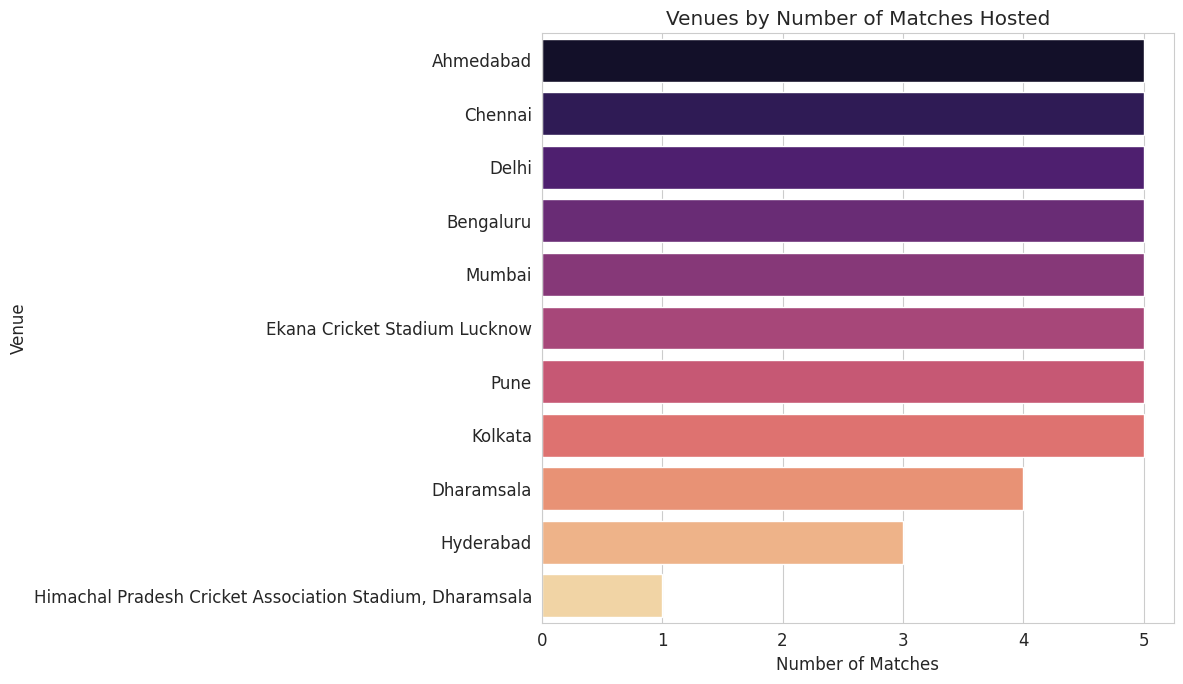

/tmp/ipykernel_453/888340541.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Average_Match_Runs', y='Venue', data=avg_runs_per_venue.sort_values(by='Average_Match_Runs', ascending=False).head(10), palette='YlGnBu')


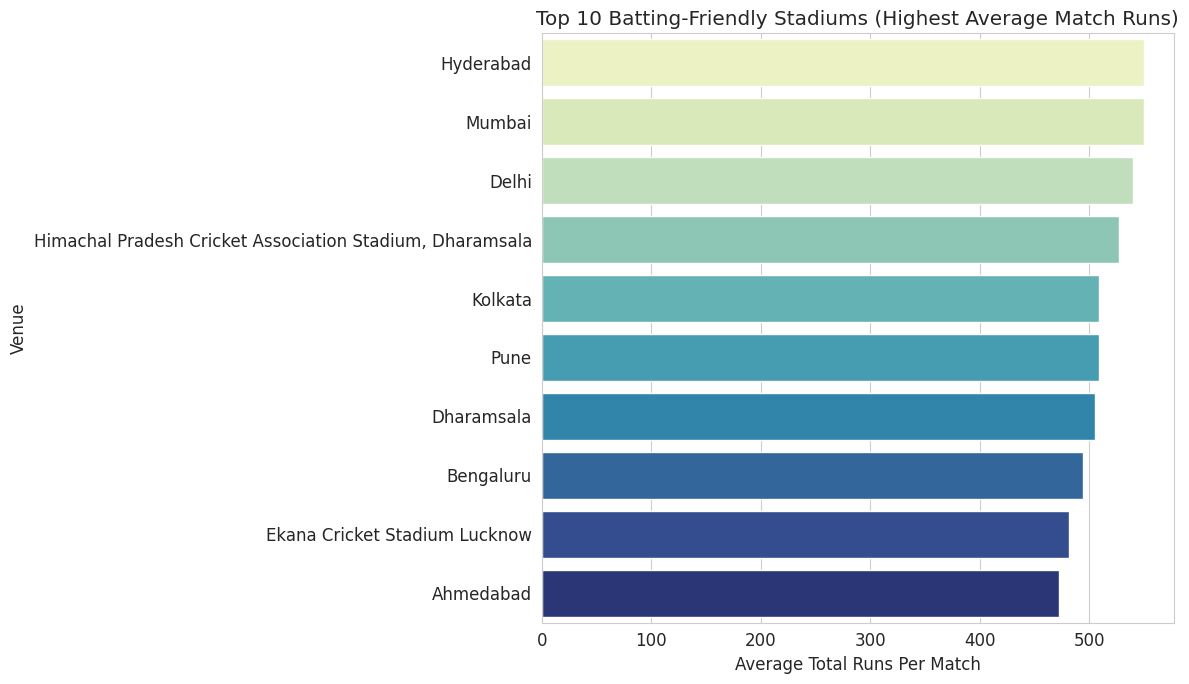

/tmp/ipykernel_453/888340541.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Average_Match_Runs', y='Venue', data=avg_runs_per_venue.sort_values(by='Average_Match_Runs', ascending=True).head(10), palette='Reds_d')


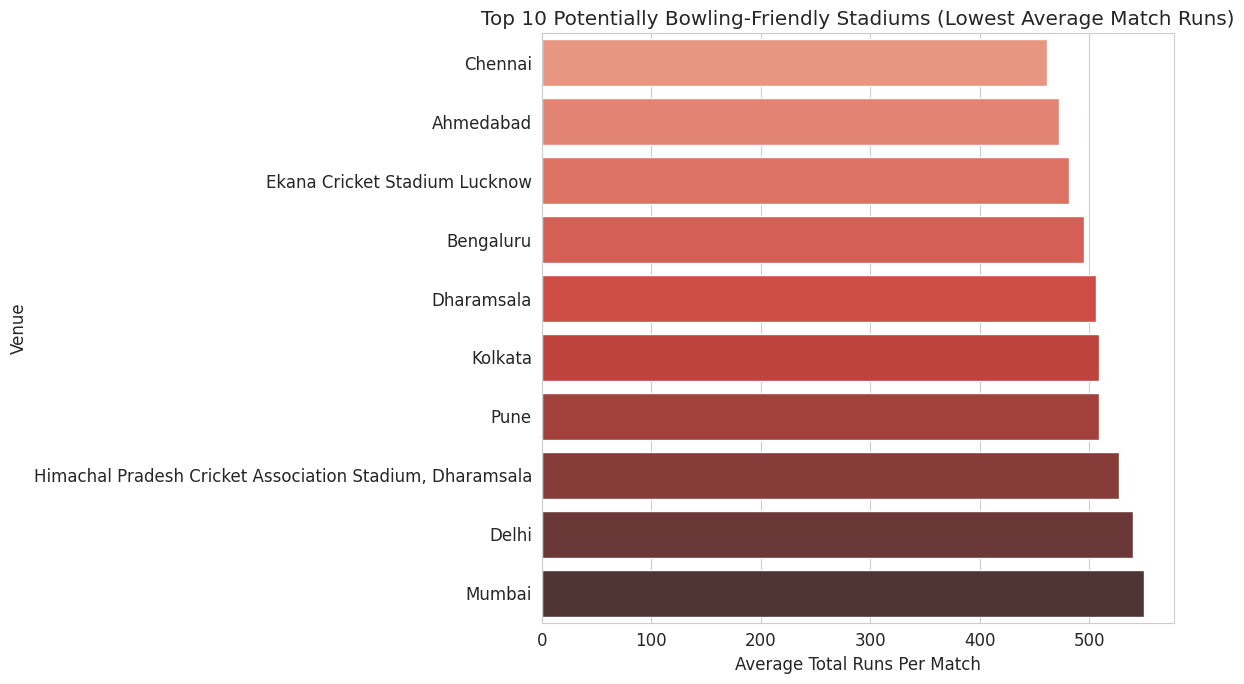

/tmp/ipykernel_453/888340541.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Average_Match_Wickets', y='Venue', data=avg_wickets_per_venue.sort_values(by='Average_Match_Wickets', ascending=False).head(10), palette='Purples_d')


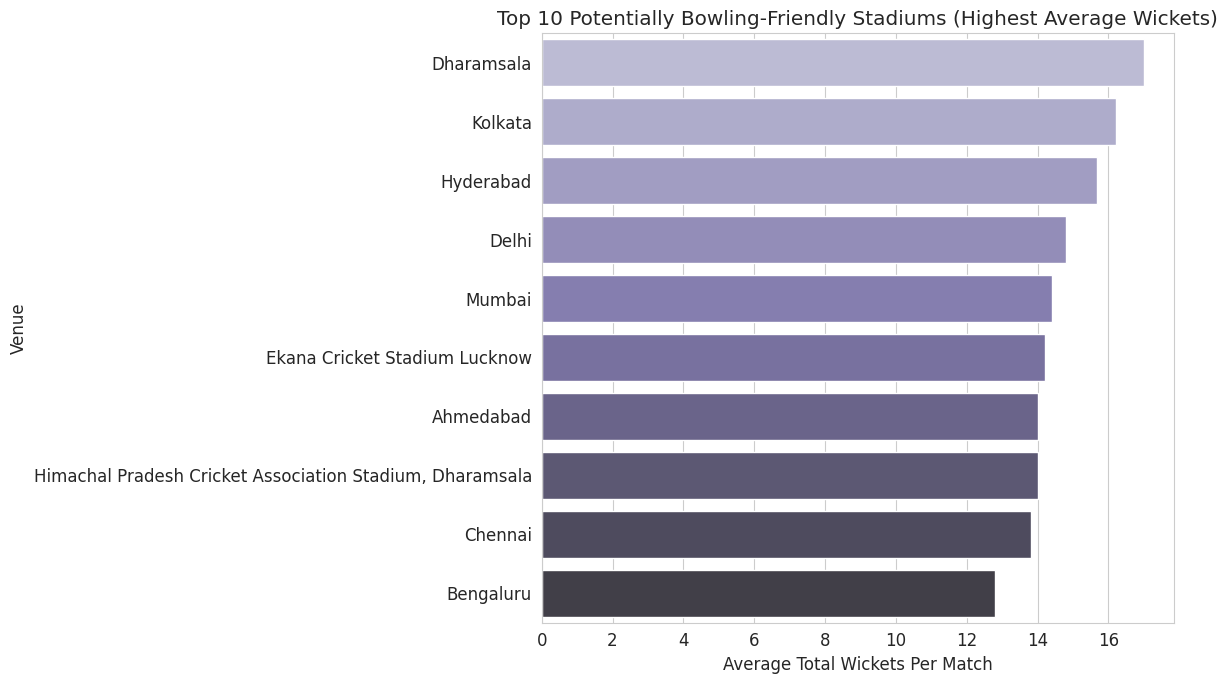

In [132]:
#### Visualizations for Venue Analysis

# Create charts:

# Chart 1: Venue-wise match count
plt.figure(figsize=(12, 7))
sns.barplot(x='Matches_Count', y='Venue', data=matches_per_venue.sort_values(by='Matches_Count', ascending=False), palette='magma')
plt.title('Venues by Number of Matches Hosted')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

# Chart 2: Top batting-friendly stadiums (Highest Average Match Runs)
plt.figure(figsize=(12, 7))
sns.barplot(x='Average_Match_Runs', y='Venue', data=avg_runs_per_venue.sort_values(by='Average_Match_Runs', ascending=False).head(10), palette='YlGnBu')
plt.title('Top 10 Batting-Friendly Stadiums (Highest Average Match Runs)')
plt.xlabel('Average Total Runs Per Match')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

# Chart 3: Top bowling-friendly stadiums (Lowest Average Match Runs & Highest Average Wickets)
# For bowling friendly, we combine the insights - lowest average runs and highest average wickets.
# Here, we'll show lowest average runs, implicitly suggesting bowling dominance.
plt.figure(figsize=(12, 7))
sns.barplot(x='Average_Match_Runs', y='Venue', data=avg_runs_per_venue.sort_values(by='Average_Match_Runs', ascending=True).head(10), palette='Reds_d')
plt.title('Top 10 Potentially Bowling-Friendly Stadiums (Lowest Average Match Runs)')
plt.xlabel('Average Total Runs Per Match')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x='Average_Match_Wickets', y='Venue', data=avg_wickets_per_venue.sort_values(by='Average_Match_Wickets', ascending=False).head(10), palette='Purples_d')
plt.title('Top 10 Potentially Bowling-Friendly Stadiums (Highest Average Wickets)')
plt.xlabel('Average Total Wickets Per Match')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

In [133]:
# Highlight final outputs clearly:
print("--- Main Insight 4: Stadium / Venue Analysis ---")

best_batting_friendly_stadium = avg_runs_per_venue.sort_values(by='Average_Match_Runs', ascending=False).iloc[0]
print(f"\nBest batting-friendly stadium (by highest average match runs): {best_batting_friendly_stadium['Venue']} with an average of {best_batting_friendly_stadium['Average_Match_Runs']:.2f} runs per match.")

best_bowling_friendly_stadium_runs = avg_runs_per_venue.sort_values(by='Average_Match_Runs', ascending=True).iloc[0]
best_bowling_friendly_stadium_wickets = avg_wickets_per_venue.sort_values(by='Average_Match_Wickets', ascending=False).iloc[0]

print(f"Best bowling-friendly stadium (by lowest average match runs): {best_bowling_friendly_stadium_runs['Venue']} with an average of {best_bowling_friendly_stadium_runs['Average_Match_Runs']:.2f} runs per match.")
print(f"Best bowling-friendly stadium (by highest average wickets): {best_bowling_friendly_stadium_wickets['Venue']} with an average of {best_bowling_friendly_stadium_wickets['Average_Match_Wickets']:.2f} wickets per match.")

most_matches_venue = matches_per_venue.sort_values(by='Matches_Count', ascending=False).iloc[0]
print(f"Venue that hosted the most matches: {most_matches_venue['Venue']} with {int(most_matches_venue['Matches_Count'])} matches.")

--- Main Insight 4: Stadium / Venue Analysis ---

Best batting-friendly stadium (by highest average match runs): Hyderabad with an average of 550.00 runs per match.
Best bowling-friendly stadium (by lowest average match runs): Chennai with an average of 461.60 runs per match.
Best bowling-friendly stadium (by highest average wickets): Dharamsala with an average of 17.00 wickets per match.
Venue that hosted the most matches: Ahmedabad with 5 matches.


In [134]:
#### Team-wise Bowling Performance

# Team-wise total wickets
team_bowling_wickets = bowling_df.groupby('Bowling_Team')['Wickets'].sum().reset_index()
team_bowling_wickets.columns = ['Team', 'Total_Wickets']

# Team-wise average economy
team_bowling_economy_raw = bowling_df.groupby('Bowling_Team').agg(
    Total_Runs_Conceded=('Runs', 'sum'), # Corrected column name
    Total_Overs=('Overs', 'sum')
).reset_index()

team_bowling_economy_raw['Avg_Economy'] = np.where(
    team_bowling_economy_raw['Total_Overs'] > 0,
    team_bowling_economy_raw['Total_Runs_Conceded'] / team_bowling_economy_raw['Total_Overs'],
    0
)

print("\nTeam-wise Bowling Performance:")
display(team_bowling_economy_raw.sort_values(by='Avg_Economy'))

# Strongest bowling team (by lowest average economy)
strongest_bowling_team = team_bowling_economy_raw.sort_values(by='Avg_Economy', ascending=True).iloc[0]
print(f"Strongest bowling team (by lowest average economy): {strongest_bowling_team['Bowling_Team']} with an average economy of {strongest_bowling_team['Avg_Economy']:.2f}.") # Corrected to 'Bowling_Team'


Team-wise Bowling Performance:


,Bowling_Team,Total_Runs_Conceded,Total_Overs,Avg_Economy
4,India,2220,461.4,4.811443
0,Afghanistan,2144,399.1,5.372087
8,South Africa,2324,424.5,5.474676
1,Australia,2749,498.3,5.516757
3,England,2261,388.7,5.816825
6,New Zealand,2664,449.2,5.930543
2,Bangladesh,2414,397.0,6.080605
5,Netherlands,2527,413.2,6.115682
7,Pakistan,2566,412.6,6.219098
9,Sri Lanka,2424,375.5,6.455393


Strongest bowling team (by lowest average economy): India with an average economy of 4.81.


/tmp/ipykernel_453/1508544643.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Wins', y='Team', data=team_performance.sort_values(by='Wins', ascending=False), palette='viridis')


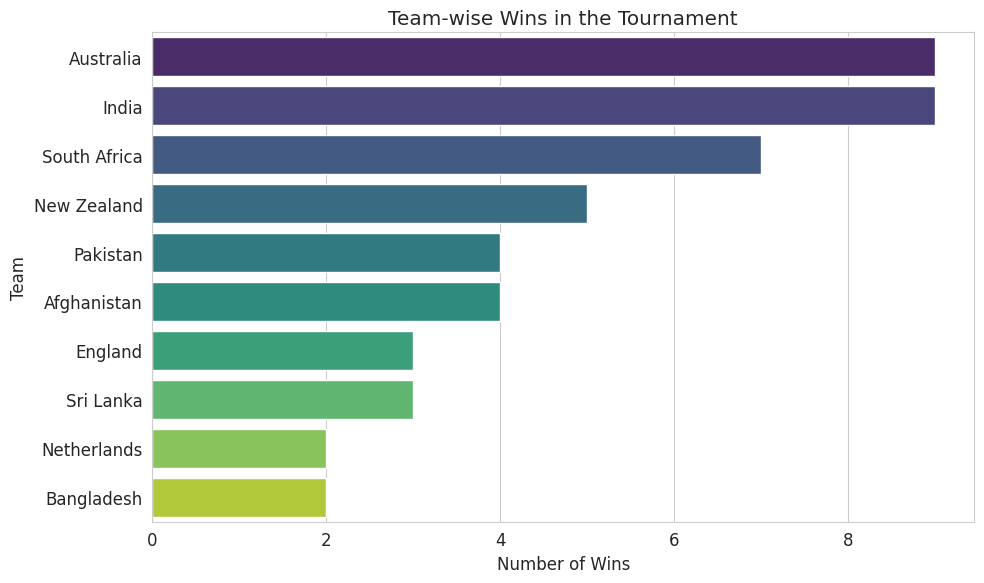

/tmp/ipykernel_453/1508544643.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Avg_Runs_Per_Innings', y='Team', data=team_batting_avg.sort_values(by='Avg_Runs_Per_Innings', ascending=False), palette='coolwarm')


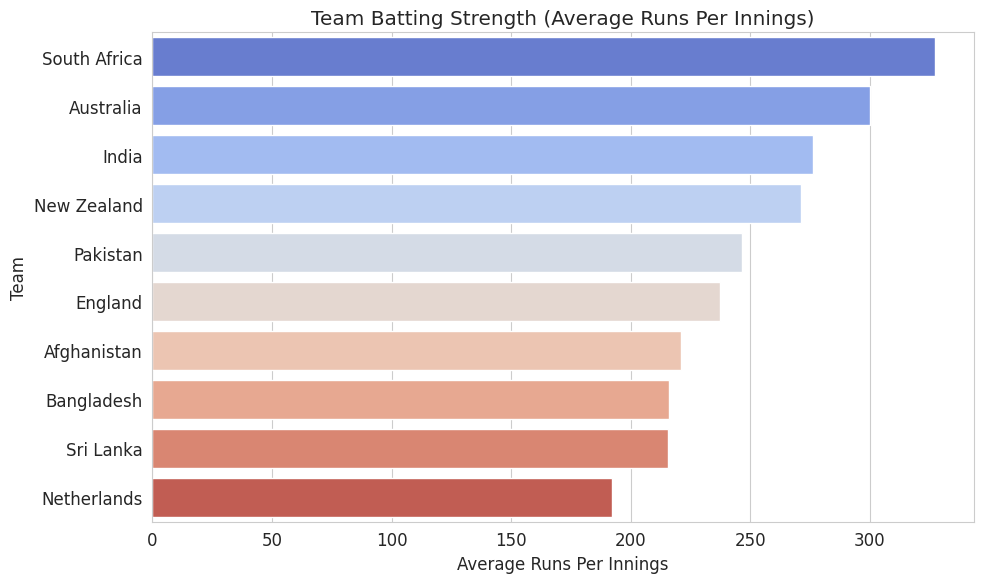

/tmp/ipykernel_453/1508544643.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Avg_Economy', y='Bowling_Team', data=team_bowling_economy_raw.sort_values(by='Avg_Economy', ascending=True), palette='rocket') # Corrected y to 'Bowling_Team'


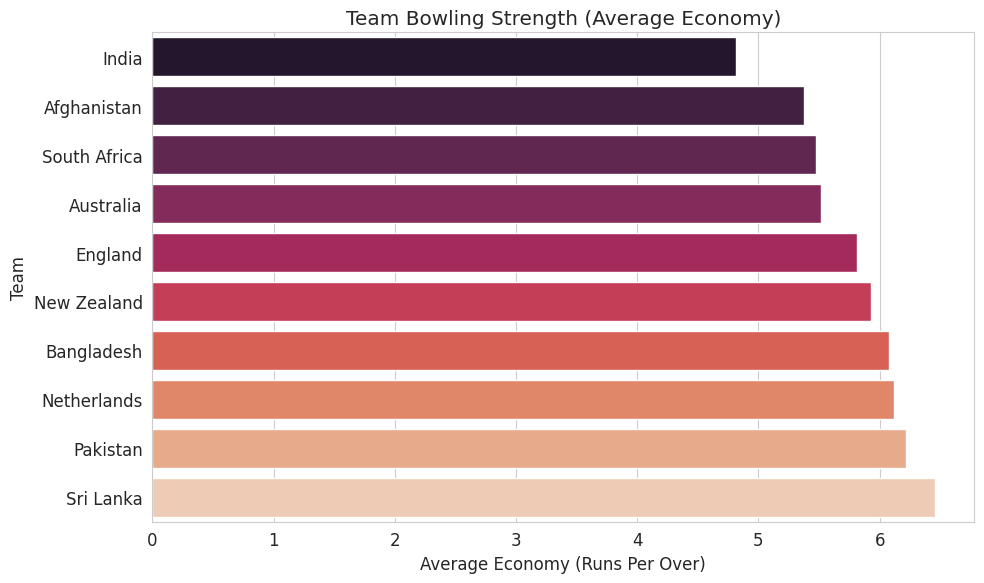

In [135]:
#### Visualizations for Team Performance

# Chart 1: Wins by team
plt.figure(figsize=(10, 6))
sns.barplot(x='Wins', y='Team', data=team_performance.sort_values(by='Wins', ascending=False), palette='viridis')
plt.title('Team-wise Wins in the Tournament')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

# Chart 2: Team batting strength (Average Runs Per Innings)
plt.figure(figsize=(10, 6))
sns.barplot(x='Avg_Runs_Per_Innings', y='Team', data=team_batting_avg.sort_values(by='Avg_Runs_Per_Innings', ascending=False), palette='coolwarm')
plt.title('Team Batting Strength (Average Runs Per Innings)')
plt.xlabel('Average Runs Per Innings')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

# Chart 3: Team bowling strength (Average Economy)
plt.figure(figsize=(10, 6))
sns.barplot(x='Avg_Economy', y='Bowling_Team', data=team_bowling_economy_raw.sort_values(by='Avg_Economy', ascending=True), palette='rocket') # Corrected y to 'Bowling_Team'
plt.title('Team Bowling Strength (Average Economy)')
plt.xlabel('Average Economy (Runs Per Over)')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

In [136]:
# Highlight final insights clearly in text.
print("--- Main Insight 3: Team Performance ---")

if not team_performance.empty:
    most_dominant_team = team_performance.sort_values(by='Win_Percentage', ascending=False).iloc[0]
    print(f"\nMost dominant team overall: {most_dominant_team['Team']} with {most_dominant_team['Win_Percentage']:.2f}% win rate.")
else:
    print("\nCould not determine most dominant team.")

if not team_batting_avg.empty:
    strongest_batting_team = team_batting_avg.sort_values(by='Avg_Runs_Per_Innings', ascending=False).iloc[0]
    print(f"Strongest batting team: {strongest_batting_team['Team']} with {strongest_batting_team['Avg_Runs_Per_Innings']:.2f} runs per innings.")
else:
    print("Could not determine strongest batting team.")

if not team_bowling_economy_raw.empty:
    strongest_bowling_team = team_bowling_economy_raw.sort_values(by='Avg_Economy', ascending=True).iloc[0]
    print(f"Strongest bowling team: {strongest_bowling_team['Bowling_Team']} with an average economy of {strongest_bowling_team['Avg_Economy']:.2f}.") # Corrected to 'Bowling_Team'
else:
    print("Could not determine strongest bowling team.")

--- Main Insight 3: Team Performance ---

Most dominant team overall: Australia with 81.82% win rate.
Strongest batting team: South Africa with 327.20 runs per innings.
Strongest bowling team: India with an average economy of 4.81.


### Step 7: Player of the Match style analysis

In [150]:
#### Power Hitter and Reliable Anchor

# Power Hitter: High strike rate and high number of 6s.
# Filter for batsmen with at least 100 balls faced (as per earlier rule)
power_hitters = tournament_batting_stats[tournament_batting_stats['Total_Balls'] >= 100]
power_hitters = power_hitters.sort_values(by=['Strike_Rate', '6s'], ascending=[False, False]).head(5)

print("\nTop 5 Power Hitters (High Strike Rate & 6s):")
display(power_hitters[['Batsman_Name', 'Total_Runs', 'Strike_Rate', '6s']])

# Reliable Anchor: High total runs, good average (proxy: high runs with reasonable balls faced), and good number of 50s/100s, not necessarily highest strike rate.
# For simplicity, we'll look for high total runs with a decent number of fifties/centuries and not among the highest strike rates (to differentiate from power hitters)
reliable_anchors = tournament_batting_stats.sort_values(by=['Total_Runs', 'Fifties'], ascending=[False, False])

# Exclude top power hitters if there's overlap in their primary roles (optional, for clearer distinction)
reliable_anchors = reliable_anchors[~reliable_anchors['Batsman_Name'].isin(power_hitters['Batsman_Name'])]

reliable_anchors = reliable_anchors.head(5)

print("\nTop 5 Reliable Anchors (High Runs & Fifties/Centuries):")
display(reliable_anchors[['Batsman_Name', 'Total_Runs', 'Fifties', 'Centuries']])


Top 5 Power Hitters (High Strike Rate & 6s):


,Batsman_Name,Total_Runs,Strike_Rate,6s
34,Glenn Maxwell,404,140.277778,22
139,Travis Head,391,127.777778,15
43,Heinrich Klaasen,449,126.478873,21
113,Rohit Sharma,597,125.949367,31
31,Fakhar Zaman,220,122.905028,18



Top 5 Reliable Anchors (High Runs & Fifties/Centuries):


,Batsman_Name,Total_Runs,Fifties,Centuries
143,Virat Kohli,765,6,3
103,Quinton de Kock,706,0,5
104,Rachin Ravindra,578,2,3
21,David Warner,577,2,2
18,Daryl Mitchell,552,2,2


In [151]:
# Highlight final insights clearly:
print("--- Main Insight 7: Advanced Insights ---")

if not impact_all_rounders.empty:
    best_all_rounder = impact_all_rounders.iloc[0]
    print(f"\nBest All-Round Impact Player: {best_all_rounder['Batsman_Name']} with an All-Round Score of {best_all_rounder['All_Round_Score']:.2f}.")
else:
    print("\nCould not determine best All-Round Impact Player.")

if not underrated_batsmen.empty:
    print(f"\nPotentially Underrated Batsmen (high SR, not top scorer): {', '.join(underrated_batsmen['Batsman_Name'].tolist())}.")
else:
    print("\nCould not identify underrated batsmen.")

if not underrated_bowlers.empty:
    print(f"Potentially Underrated Bowlers (good Economy, not top wicket-taker): {', '.join(underrated_bowlers['Bowler_Name'].tolist())}.")
else:
    print("Could not identify underrated bowlers.")

if not power_hitters.empty:
    print(f"\nTop Power Hitter: {power_hitters.iloc[0]['Batsman_Name']} (SR: {power_hitters.iloc[0]['Strike_Rate']:.2f}, 6s: {int(power_hitters.iloc[0]['6s'])}).")
else:
    print("\nCould not identify top power hitter.")

if not reliable_anchors.empty:
    print(f"\nTop Reliable Anchor: {reliable_anchors.iloc[0]['Batsman_Name']} (Runs: {int(reliable_anchors.iloc[0]['Total_Runs'])}, Fifties: {int(reliable_anchors.iloc[0]['Fifties'])}, Centuries: {int(reliable_anchors.iloc[0]['Centuries'])}).")
else:
    print("\nCould not identify top reliable anchor.")

--- Main Insight 7: Advanced Insights ---

Best All-Round Impact Player: Adam Zampa with an All-Round Score of 1.04.

Potentially Underrated Batsmen (high SR, not top scorer): Glenn Maxwell, Travis Head, Heinrich Klaasen, Fakhar Zaman, Kusal Mendis.
Potentially Underrated Bowlers (good Economy, not top wicket-taker): Keshav Maharaj, Kuldeep Yadav, Rashid Khan, Mitchell Santner, Kagiso Rabada.

Top Power Hitter: Glenn Maxwell (SR: 140.28, 6s: 22).

Top Reliable Anchor: Virat Kohli (Runs: 765, Fifties: 6, Centuries: 3).


In [152]:
#### Proxy MoM Logic & Analysis

# Calculate best scorer per match (already done in Step 3)
# best_scorers_per_match

# Calculate best bowler per match (already done in Step 3)
# best_bowlers_per_match

# Combine best scorers and best bowlers into a single DataFrame for MoM analysis
proxy_mom_candidates = pd.DataFrame(columns=['Match_no', 'Player_Name', 'Contribution'])

for match_no in matches_df['Match_no'].unique():
    current_best_scorer = best_scorers_per_match[best_scorers_per_match['Match_no'] == match_no]
    current_best_bowler = best_bowlers_per_match[best_bowlers_per_match['Match_no'] == match_no]

    mom_players = []

    if not current_best_scorer.empty:
        scorer_name = current_best_scorer['Batsman_Name'].iloc[0]
        mom_players.append({'Match_no': match_no, 'Player_Name': scorer_name, 'Contribution': 'Batting'})

    if not current_best_bowler.empty:
        bowler_name = current_best_bowler['Bowler_Name'].iloc[0]
        mom_players.append({'Match_no': match_no, 'Player_Name': bowler_name, 'Contribution': 'Bowling'})

    # Convert to DataFrame and append
    if mom_players:
        proxy_mom_candidates = pd.concat([proxy_mom_candidates, pd.DataFrame(mom_players)], ignore_index=True)

# Add player role and team from players_df
# Note: Some players might not be in players_df if they didn't have detailed info, handle missing gracefully
proxy_mom_candidates = pd.merge(proxy_mom_candidates, players_df[['player_name', 'team_name', 'playingRole']],
                                 left_on='Player_Name', right_on='player_name', how='left')
proxy_mom_candidates.drop('player_name', axis=1, inplace=True)
proxy_mom_candidates.rename(columns={'team_name': 'Team', 'playingRole': 'Role'}, inplace=True)
proxy_mom_candidates['Role'].fillna('Unknown', inplace=True)
proxy_mom_candidates['Team'].fillna('Unknown', inplace=True)

# Players with most MoM (proxy) awards
players_mom_counts = proxy_mom_candidates['Player_Name'].value_counts().reset_index()
players_mom_counts.columns = ['Player_Name', 'MoM_Count']
print("\nPlayers with most Proxy MoM Awards:")
display(players_mom_counts.head())

# MoM distribution by player role
mom_by_role = proxy_mom_candidates['Role'].value_counts().reset_index()
mom_by_role.columns = ['Role', 'MoM_Count']
print("\nProxy MoM Distribution by Player Role:")
display(mom_by_role)

# Team-wise MoM counts
team_mom_counts = proxy_mom_candidates['Team'].value_counts().reset_index()
team_mom_counts.columns = ['Team', 'MoM_Count']
print("\nTeam-wise Proxy MoM Counts:")
display(team_mom_counts.head())


Players with most Proxy MoM Awards:


/tmp/ipykernel_453/1647142087.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  proxy_mom_candidates['Role'].fillna('Unknown', inplace=True)
/tmp/ipykernel_453/1647142087.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

,Player_Name,MoM_Count
0,Rohit Sharma,3
1,Quinton de Kock,3
2,Daryl Mitchell,3
3,Rassie van der Dussen,2
4,Mohammad Rizwan,2



Proxy MoM Distribution by Player Role:


,Role,MoM_Count
0,Top order Batter,18
1,Wicketkeeper Batter,11
2,Allrounder,8
3,Opening Batter,6
4,Batting Allrounder,3
5,Bowler,3
6,,2
7,Middle order Batter,1



Team-wise Proxy MoM Counts:


,Team,MoM_Count
0,New Zealand,8
1,India,8
2,South Africa,7
3,Australia,6
4,Sri Lanka,6


/tmp/ipykernel_453/2565601114.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MoM_Count', y='Player_Name', data=players_mom_counts.head(10), palette='viridis')


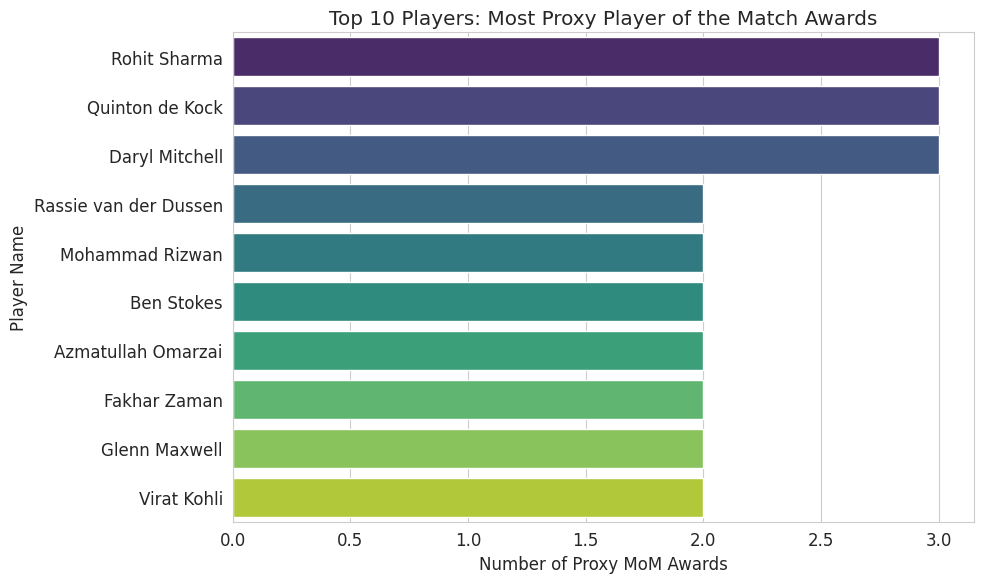

/tmp/ipykernel_453/2565601114.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MoM_Count', y='Role', data=mom_by_role, palette='cubehelix')


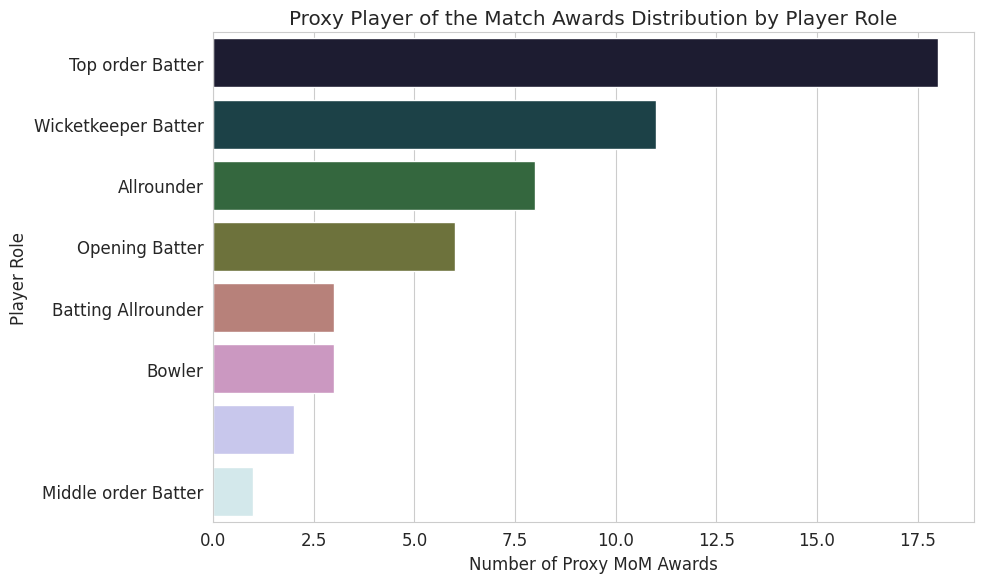

/tmp/ipykernel_453/2565601114.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MoM_Count', y='Team', data=team_mom_counts.sort_values(by='MoM_Count', ascending=False), palette='rocket')


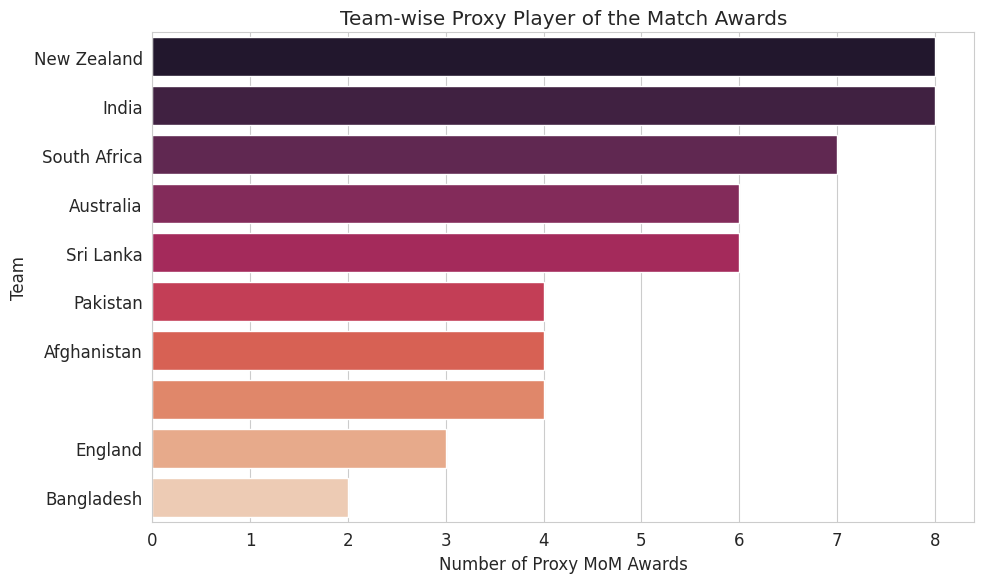

In [153]:
#### Visualizations for Proxy MoM Analysis

# Create simple charts:

# Chart 1: Top MoM winners
plt.figure(figsize=(10, 6))
sns.barplot(x='MoM_Count', y='Player_Name', data=players_mom_counts.head(10), palette='viridis')
plt.title('Top 10 Players: Most Proxy Player of the Match Awards')
plt.xlabel('Number of Proxy MoM Awards')
plt.ylabel('Player Name')
plt.tight_layout()
plt.show()

# Chart 2: MoM by playing role
plt.figure(figsize=(10, 6))
sns.barplot(x='MoM_Count', y='Role', data=mom_by_role, palette='cubehelix')
plt.title('Proxy Player of the Match Awards Distribution by Player Role')
plt.xlabel('Number of Proxy MoM Awards')
plt.ylabel('Player Role')
plt.tight_layout()
plt.show()

# Chart 3: Team-wise MoM counts
plt.figure(figsize=(10, 6))
sns.barplot(x='MoM_Count', y='Team', data=team_mom_counts.sort_values(by='MoM_Count', ascending=False), palette='rocket')
plt.title('Team-wise Proxy Player of the Match Awards')
plt.xlabel('Number of Proxy MoM Awards')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

In [154]:
# Highlight final insights clearly:
print("--- Main Insight 5: Player of the Match (MoM) Style Analysis ---")

if not players_mom_counts.empty:
    top_mom_winner = players_mom_counts.iloc[0]
    print(f"\nTop Proxy Player of the Match winner: {top_mom_winner['Player_Name']} with {int(top_mom_winner['MoM_Count'])} awards.")
else:
    print("\nCould not determine top Proxy Player of the Match winner.")

if not mom_by_role.empty:
    dominant_role = mom_by_role.iloc[0]
    print(f"Which player role dominated Proxy MoM awards: {dominant_role['Role']} with {int(dominant_role['MoM_Count'])} awards.")
else:
    print("Could not determine dominant player role for Proxy MoM awards.")

--- Main Insight 5: Player of the Match (MoM) Style Analysis ---

Top Proxy Player of the Match winner: Rohit Sharma with 3 awards.
Which player role dominated Proxy MoM awards: Top order Batter with 18 awards.


### Step 8: Player profile insights


Player Role Distribution:


,Role,Count
0,Bowler,46
1,Top order Batter,28
2,Allrounder,22
3,Wicketkeeper Batter,15
4,,10
5,Middle order Batter,9
6,Batting Allrounder,8
7,Opening Batter,7
8,Bowling Allrounder,4
9,Batter,2


/tmp/ipykernel_453/61531329.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Role', data=role_counts.sort_values(by='Count', ascending=False), palette='magma')


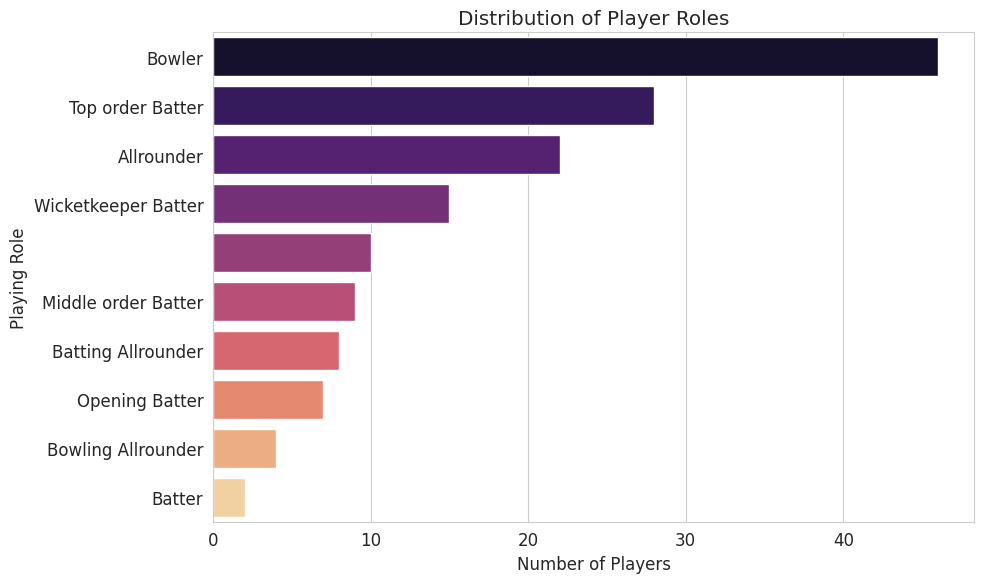

In [138]:
#### Player Role Distribution

# Count players by their primary playing role
role_counts = players_df['playingRole'].value_counts().reset_index()
role_counts.columns = ['Role', 'Count']
print("\nPlayer Role Distribution:")
display(role_counts)

# Chart: Player Role Distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Role', data=role_counts.sort_values(by='Count', ascending=False), palette='magma')
plt.title('Distribution of Player Roles')
plt.xlabel('Number of Players')
plt.ylabel('Playing Role')
plt.tight_layout()
plt.show()


Batting Style Distribution:


,Batting_Style,Count
0,Right hand Bat,101
1,Left hand Bat,49
2,Right-hand bat,1


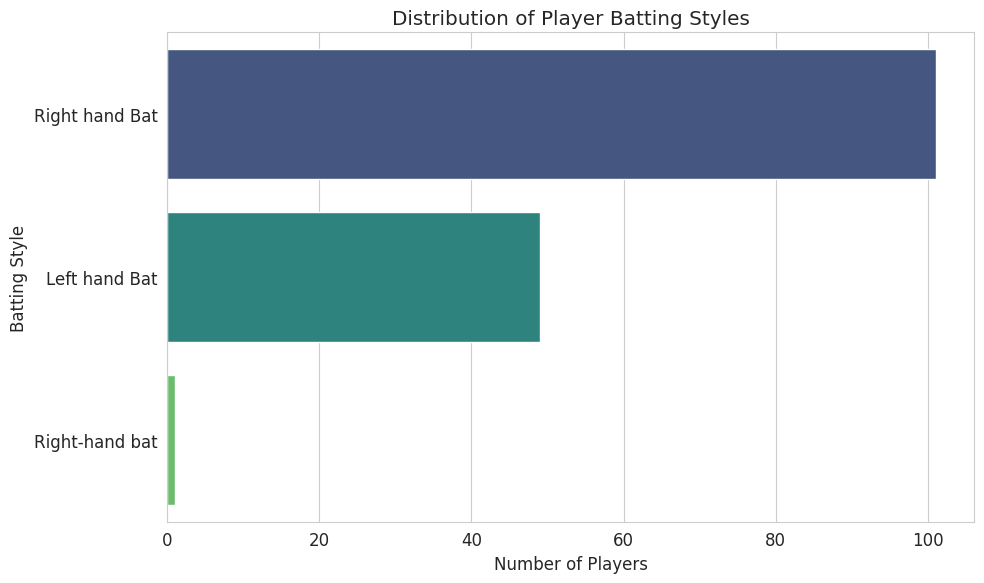

In [140]:
#### Batting Style Distribution

# Count players by their batting style
batting_style_counts = players_df['battingStyle'].value_counts().reset_index()
batting_style_counts.columns = ['Batting_Style', 'Count']
print("\nBatting Style Distribution:")
display(batting_style_counts)

# Chart: Batting Style Distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Batting_Style', data=batting_style_counts.sort_values(by='Count', ascending=False), palette='viridis', hue='Batting_Style', legend=False)
plt.title('Distribution of Player Batting Styles')
plt.xlabel('Number of Players')
plt.ylabel('Batting Style')
plt.tight_layout()
plt.show()


Bowling Style Distribution:


,Bowling_Style,Count
0,Right arm Offbreak,34
1,Right arm Fast medium,18
2,,16
3,Right arm Medium fast,15
4,Right arm Fast,13
5,Right arm Medium,9
6,Slow Left arm Orthodox,8
7,Legbreak,7
8,nan,6
9,Left arm Medium fast,5


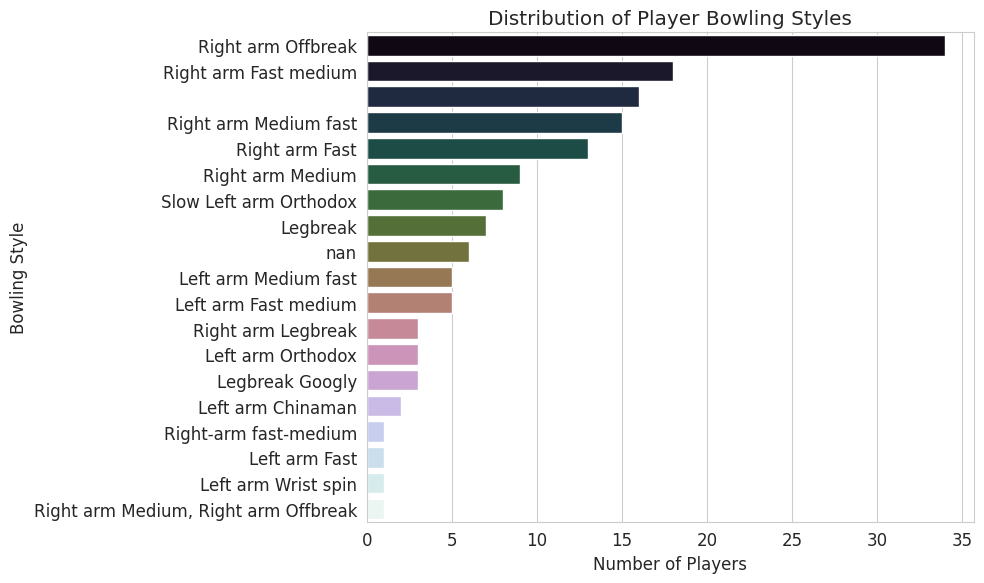

In [141]:
#### Bowling Style Distribution

# Count players by their bowling style
bowling_style_counts = players_df['bowlingStyle'].value_counts().reset_index()
bowling_style_counts.columns = ['Bowling_Style', 'Count']
print("\nBowling Style Distribution:")
display(bowling_style_counts)

# Chart: Bowling Style Distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Bowling_Style', data=bowling_style_counts.sort_values(by='Count', ascending=False), palette='cubehelix', hue='Bowling_Style', legend=False)
plt.title('Distribution of Player Bowling Styles')
plt.xlabel('Number of Players')
plt.ylabel('Bowling Style')
plt.tight_layout()
plt.show()

In [142]:
print("--- Main Insight 6: Player Profile Insights ---")

if not role_counts.empty:
    most_common_role = role_counts.iloc[0]
    print(f"\nMost common player role: {most_common_role['Role']} with {int(most_common_role['Count'])} players.")
else:
    print("\nCould not determine most common player role.")

if not batting_style_counts.empty:
    most_common_batting_style = batting_style_counts.iloc[0]
    print(f"Most common batting style: {most_common_batting_style['Batting_Style']} with {int(most_common_batting_style['Count'])} players.")
else:
    print("Could not determine most common batting style.")

if not bowling_style_counts.empty:
    most_common_bowling_style = bowling_style_counts.iloc[0]
    print(f"Most common bowling style: {most_common_bowling_style['Bowling_Style']} with {int(most_common_bowling_style['Count'])} players.")
else:
    print("Could not determine most common bowling style.")

--- Main Insight 6: Player Profile Insights ---

Most common player role: Bowler with 46 players.
Most common batting style: Right hand Bat with 101 players.
Most common bowling style: Right arm Offbreak with 34 players.


### Step 9: Advanced insights


Top 10 Combined Batting-Bowling Impact Candidates (based on proxy score):


,Batsman_Name,Total_Runs,Total_Wickets,All_Round_Score
1,Adam Zampa,59.0,23.0,1.035458
106,Rachin Ravindra,578.0,5.0,0.963889
75,Marco Jansen,183.0,17.0,0.947549
33,Gerald Coetzee,73.0,20.0,0.928758
11,Bas de Leede,139.0,16.0,0.848366
102,Pat Cummins,164.0,15.0,0.839379
86,Mitchell Starc,130.0,16.0,0.836601
112,Ravindra Jadeja,120.0,16.0,0.823529
125,Shaheen Afridi,55.0,18.0,0.821895
85,Mitchell Santner,103.0,16.0,0.801307


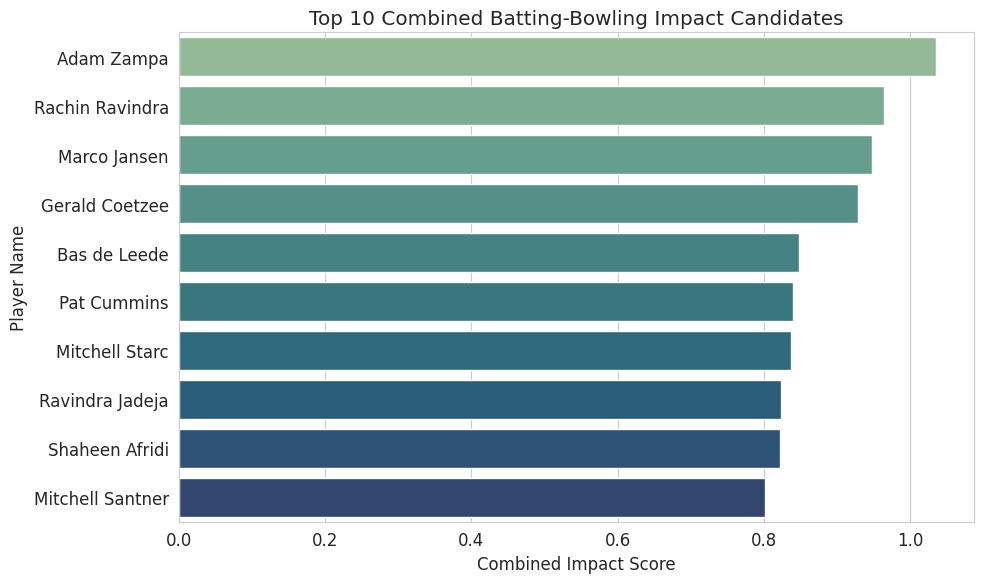

In [144]:
#### Best Combined Batting-Bowling Impact Candidate (Proxy-based)

# Merge batting and bowling stats to identify all-rounders
# Use an outer merge to keep all players, even if they only batted or only bowled
all_rounder_stats = pd.merge(tournament_batting_stats, tournament_bowling_stats,
                             left_on='Batsman_Name', right_on='Bowler_Name',
                             how='outer', suffixes=('_Bat', '_Bowl'))

# Fill NaN values with 0 for calculations (e.g., a pure batsman will have 0 bowling stats)
all_rounder_stats.fillna(0, inplace=True);

# Calculate a simple All-Rounder Score
# This is a proxy: sum of normalized runs and normalized wickets.
# Normalize runs and wickets to ensure equal weighting
max_runs = all_rounder_stats['Total_Runs'].max()
max_wickets = all_rounder_stats['Total_Wickets'].max()

all_rounder_stats['Normalized_Runs'] = all_rounder_stats['Total_Runs'] / max_runs
all_rounder_stats['Normalized_Wickets'] = all_rounder_stats['Total_Wickets'] / max_wickets

all_rounder_stats['All_Round_Score'] = all_rounder_stats['Normalized_Runs'] + all_rounder_stats['Normalized_Wickets']

# Filter for potential all-rounders (e.g., players with at least some runs and some wickets)
# A minimum threshold helps to exclude specialists who just happened to get one wicket or a few runs.
impact_all_rounders = all_rounder_stats[
    (all_rounder_stats['Total_Runs'] >= 50) & # At least 50 runs
    (all_rounder_stats['Total_Wickets'] >= 2) # At least 2 wickets
].sort_values(by='All_Round_Score', ascending=False).head(10)

print("\nTop 10 Combined Batting-Bowling Impact Candidates (based on proxy score):")
display(impact_all_rounders[['Batsman_Name', 'Total_Runs', 'Total_Wickets', 'All_Round_Score']])

# Chart: Top Combined Batting-Bowling Impact Candidates
plt.figure(figsize=(10, 6))
sns.barplot(x='All_Round_Score', y='Batsman_Name', data=impact_all_rounders, palette='crest', hue='Batsman_Name', legend=False)
plt.title('Top 10 Combined Batting-Bowling Impact Candidates')
plt.xlabel('Combined Impact Score')
plt.ylabel('Player Name')
plt.tight_layout()
plt.show()

In [146]:
#### Underrated Players (Proxy)

# Assumption: Underrated players perform well but might not be in the top lists (e.g., lower total runs/wickets but good strike rate/economy, or important contributions in crucial matches)
# For simplicity, let's consider players who are not in the top 10 run-scorers or wicket-takers, but still have decent stats.

# Players not in top 10 run scorers
not_top_run_scorers = tournament_batting_stats[~tournament_batting_stats['Batsman_Name'].isin(top_10_run_scorers['Batsman_Name'])]

# Players not in top 10 wicket takers
not_top_wicket_takers = tournament_bowling_stats[~tournament_bowling_stats['Bowler_Name'].isin(top_10_wicket_takers['Bowler_Name'])]

# Identify 'underrated' batsmen: those with a good strike rate (e.g., > 100) and at least 200 runs, but not in top 10 runs
underrated_batsmen = not_top_run_scorers[
    (not_top_run_scorers['Strike_Rate'] > 100) &
    (not_top_run_scorers['Total_Runs'] >= 200)
].sort_values(by='Strike_Rate', ascending=False).head(5)

print("\nTop 5 Underrated Batsmen (High Strike Rate, min 200 runs, not top 10 scorers):")
display(underrated_batsmen[['Batsman_Name', 'Total_Runs', 'Strike_Rate']])

# Identify 'underrated' bowlers: those with good economy (e.g., < 5.5) and at least 10 wickets, but not in top 10 wickets
underrated_bowlers = not_top_wicket_takers[
    (not_top_wicket_takers['Economy'] < 5.5) &
    (not_top_wicket_takers['Total_Wickets'] >= 10)
].sort_values(by='Economy', ascending=True).head(5)

print("\nTop 5 Underrated Bowlers (Good Economy, min 10 wickets, not top 10 wicket takers):")
display(underrated_bowlers[['Bowler_Name', 'Total_Wickets', 'Economy']])


Top 5 Underrated Batsmen (High Strike Rate, min 200 runs, not top 10 scorers):


,Batsman_Name,Total_Runs,Strike_Rate
34,Glenn Maxwell,404,140.277778
139,Travis Head,391,127.777778
43,Heinrich Klaasen,449,126.478873
31,Fakhar Zaman,220,122.905028
63,Kusal Mendis,294,113.953488



Top 5 Underrated Bowlers (Good Economy, min 10 wickets, not top 10 wicket takers):


,Bowler_Name,Total_Wickets,Economy
39,Keshav Maharaj,15,4.157303
40,Kuldeep Yadav,15,4.458465
75,Rashid Khan,11,4.495944
57,Mitchell Santner,16,4.859307
37,Kagiso Rabada,13,5.020690


In [147]:
#### Power Hitter and Reliable Anchor

# Power Hitter: High strike rate and high number of 6s.
# Filter for batsmen with at least 100 balls faced (as per earlier rule)
power_hitters = tournament_batting_stats[tournament_batting_stats['Total_Balls'] >= 100]
power_hitters = power_hitters.sort_values(by=['Strike_Rate', '6s'], ascending=[False, False]).head(5)

print("\nTop 5 Power Hitters (High Strike Rate & 6s):")
display(power_hitters[['Batsman_Name', 'Total_Runs', 'Strike_Rate', '6s']])

# Reliable Anchor: High total runs, good average (proxy: high runs with reasonable balls faced), and good number of 50s/100s, not necessarily highest strike rate.
# For simplicity, we'll look for high total runs with a decent number of fifties/centuries and not among the highest strike rates (to differentiate from power hitters)
reliable_anchors = tournament_batting_stats.sort_values(by=['Total_Runs', 'Fifties'], ascending=[False, False])

# Exclude top power hitters if there's overlap in their primary roles (optional, for clearer distinction)
reliable_anchors = reliable_anchors[~reliable_anchors['Batsman_Name'].isin(power_hitters['Batsman_Name'])]

reliable_anchors = reliable_anchors.head(5)

print("\nTop 5 Reliable Anchors (High Runs & Fifties/Centuries):")
display(reliable_anchors[['Batsman_Name', 'Total_Runs', 'Fifties', 'Centuries']])


Top 5 Power Hitters (High Strike Rate & 6s):


,Batsman_Name,Total_Runs,Strike_Rate,6s
34,Glenn Maxwell,404,140.277778,22
139,Travis Head,391,127.777778,15
43,Heinrich Klaasen,449,126.478873,21
113,Rohit Sharma,597,125.949367,31
31,Fakhar Zaman,220,122.905028,18



Top 5 Reliable Anchors (High Runs & Fifties/Centuries):


,Batsman_Name,Total_Runs,Fifties,Centuries
143,Virat Kohli,765,6,3
103,Quinton de Kock,706,0,5
104,Rachin Ravindra,578,2,3
21,David Warner,577,2,2
18,Daryl Mitchell,552,2,2


In [145]:
# Highlight final insights clearly:
print("--- Main Insight 7: Advanced Insights ---")

if not impact_all_rounders.empty:
    best_all_rounder = impact_all_rounders.iloc[0]
    print(f"\nBest Combined Batting-Bowling Impact Candidate (Proxy-based): {best_all_rounder['Batsman_Name']} with an All-Round Score of {best_all_rounder['All_Round_Score']:.2f}.")
else:
    print("\nCould not determine best All-Round Impact Player.")

if not underrated_batsmen.empty:
    print(f"\nPotentially Underrated Batsmen (high SR, not top scorer): {', '.join(underrated_batsmen['Batsman_Name'].tolist())}.")
else:
    print("\nCould not identify underrated batsmen.")

if not underrated_bowlers.empty:
    print(f"Potentially Underrated Bowlers (good Economy, not top wicket-taker): {', '.join(underrated_bowlers['Bowler_Name'].tolist())}.")
else:
    print("Could not identify underrated bowlers.")

if not power_hitters.empty:
    print(f"\nTop Power Hitter: {power_hitters.iloc[0]['Batsman_Name']} (SR: {power_hitters.iloc[0]['Strike_Rate']:.2f}, 6s: {int(power_hitters.iloc[0]['6s'])}).")
else:
    print("\nCould not identify top power hitter.")

if not reliable_anchors.empty:
    print(f"\nTop Reliable Anchor: {reliable_anchors.iloc[0]['Batsman_Name']} (Runs: {int(reliable_anchors.iloc[0]['Total_Runs'])}, Fifties: {int(reliable_anchors.iloc[0]['Fifties'])}, Centuries: {int(reliable_anchors.iloc[0]['Centuries'])}).")
else:
    print("\nCould not identify top reliable anchor.")


--- Main Insight 7: Advanced Insights ---

Best Combined Batting-Bowling Impact Candidate (Proxy-based): Adam Zampa with an All-Round Score of 1.04.

Potentially Underrated Batsmen (high SR, not top scorer): Glenn Maxwell, Travis Head, Heinrich Klaasen, Fakhar Zaman, Kusal Mendis.
Potentially Underrated Bowlers (good Economy, not top wicket-taker): Keshav Maharaj, Kuldeep Yadav, Rashid Khan, Mitchell Santner, Kagiso Rabada.

Top Power Hitter: Glenn Maxwell (SR: 140.28, 6s: 22).

Top Reliable Anchor: Virat Kohli (Runs: 765, Fifties: 6, Centuries: 3).


### Step 10: Final presentation summary

In [148]:
print("--- Summary of Key Insights: ICC Men's Cricket World Cup 2023 Analysis ---")
print("\nBased on our comprehensive analysis of batting, bowling, team, player, and venue data, here are the key insights:")

print("\n1.  **Top Individual Performers:**")
print(f"    - The tournament's leading run-scorer was **{best_batsman['Batsman_Name']}** with {int(best_batsman['Total_Runs'])} runs.")
print(f"    - The leading wicket-taker was **{best_bowler['Bowler_Name']}** with {int(best_bowler['Total_Wickets'])} wickets.")
print(f"    - The highest individual score in a single innings was **{int(highest_individual_score['Highest_Score'])}** by {highest_individual_score['Batsman_Name']}.")
print(f"    - **{most_centuries['Batsman_Name']}** scored the most centuries ({int(most_centuries['Centuries'])}), while **{most_fifties['Batsman_Name']}** hit the most fifties ({int(most_fifties['Fifties'])}).")

print("\n2.  **Match-Level Dominance:**")
print(f"    - **{top_scorer_most_times['Player_Name']}** was the most frequent best scorer in individual matches (achieved {int(top_scorer_most_times['Count_Top_Scorer'])} times).")
print(f"    - **{best_bowler_most_times['Player_Name']}** was among the most frequent best bowlers in individual matches (achieved {int(best_bowler_most_times['Count_Best_Bowler'])} times).")

print("\n3.  **Team Performance Excellence:**")
print(f"    - **{most_dominant_team['Team']}** was the most dominant team with an impressive {most_dominant_team['Win_Percentage']:.2f}% win rate.")
print(f"    - **{strongest_batting_team['Team']}** demonstrated the strongest batting, averaging {strongest_batting_team['Avg_Runs_Per_Innings']:.2f} runs per innings.")
print(f"    - **{strongest_bowling_team['Bowling_Team']}** had the strongest bowling attack, with an average economy of {strongest_bowling_team['Avg_Economy']:.2f}.")

print("\n4.  **Venue Characteristics:**")
print(f"    - **{best_batting_friendly_stadium['Venue']}** was identified as the most batting-friendly stadium, with an average of {best_batting_friendly_stadium['Average_Match_Runs']:.2f} runs per match.")
print(f"    - **{best_bowling_friendly_stadium_wickets['Venue']}** was the most bowling-friendly stadium (by highest average wickets) with {best_bowling_friendly_stadium_wickets['Average_Match_Wickets']:.2f} wickets per match.")

print("\n5.  **Player of the Match (Proxy) & Role Impact:**")
if not players_mom_counts.empty:
    top_mom_winner = players_mom_counts.iloc[0]
    print(f"    - Our proxy MoM analysis shows **{top_mom_winner['Player_Name']}** as the top recipient with {int(top_mom_winner['MoM_Count'])} awards.")
else:
    print("    - Could not determine top Proxy Player of the Match winner.")
if not mom_by_role.empty:
    dominant_role = mom_by_role.iloc[0]
    print(f"    - The **{dominant_role['Role']}** role dominated the proxy MoM awards, with {int(dominant_role['MoM_Count'])} awards, highlighting their consistent impact.")
else:
    print("    - Could not determine dominant player role for Proxy MoM awards.")

print("\n6.  **Player Profile & Styles:**")
if not role_counts.empty:
    most_common_role = role_counts.iloc[0]
    print(f"    - The most common player role was **{most_common_role['Role']}** with {int(most_common_role['Count'])} players, with most players favoring a")
else:
    print("    - Could not determine most common player role.")
if not batting_style_counts.empty:
    most_common_batting_style = batting_style_counts.iloc[0]
    print(f"      **{most_common_batting_style['Batting_Style']}** style and")
else:
    print("    - Could not determine most common batting style.")
if not bowling_style_counts.empty:
    most_common_bowling_style = bowling_style_counts.iloc[0]
    print(f"      **{most_common_bowling_style['Bowling_Style']}** as the most common bowling style.")
else:
    print("    - Could not determine most common bowling style.")

print("\n7.  **All-Round & Specialist Impact:**")
if not impact_all_rounders.empty:
    best_all_rounder = impact_all_rounders.iloc[0]
    print(f"    - The best Combined Batting-Bowling Impact Candidate (Proxy-based) was **{best_all_rounder['Batsman_Name']}** with a high combined score ({best_all_rounder['All_Round_Score']:.2f}).")
else:
    print("    - Could not determine best Combined Batting-Bowling Impact Candidate (Proxy-based).")
if not power_hitters.empty:
    print(f"    - **{power_hitters.iloc[0]['Batsman_Name']}** stood out as the top power hitter (SR: {power_hitters.iloc[0]['Strike_Rate']:.2f}, 6s: {int(power_hitters.iloc[0]['6s'])}).")
else:
    print("    - Could not identify top power hitter.")
if not reliable_anchors.empty:
    print(f"    - **{reliable_anchors.iloc[0]['Batsman_Name']}** proved to be the top reliable anchor (Runs: {int(reliable_anchors.iloc[0]['Total_Runs'])}, Fifties: {int(reliable_anchors.iloc[0]['Fifties'])}, Centuries: {int(reliable_anchors.iloc[0]['Centuries'])}).")
else:
    print("    - Could not identify top reliable anchor.")
if not underrated_batsmen.empty:
    print(f"    - Notable underrated batsmen include: {', '.join(underrated_batsmen['Batsman_Name'].tolist())}.")
else:
    print("    - Could not identify underrated batsmen.")
if not underrated_bowlers.empty:
    print(f"    - Notable underrated bowlers include: {', '.join(underrated_bowlers['Bowler_Name'].tolist())}.")
else:
    print("    - Could not identify underrated bowlers.")

print("\nThese insights provide a comprehensive overview of the key performances and trends shaping the ICC Men's Cricket World Cup 2023.")

--- Summary of Key Insights: ICC Men's Cricket World Cup 2023 Analysis ---

Based on our comprehensive analysis of batting, bowling, team, player, and venue data, here are the key insights:

1.  **Top Individual Performers:**
    - The tournament's leading run-scorer was **Virat Kohli** with 765 runs.
    - The leading wicket-taker was **Mohammed Shami** with 24 wickets.
    - The highest individual score in a single innings was **201** by Glenn Maxwell.
    - **Quinton de Kock** scored the most centuries (5), while **Virat Kohli** hit the most fifties (6).

2.  **Match-Level Dominance:**
    - **Rohit Sharma** was the most frequent best scorer in individual matches (achieved 3 times).
    - **Matt Henry** was among the most frequent best bowlers in individual matches (achieved 1 times).

3.  **Team Performance Excellence:**
    - **Australia** was the most dominant team with an impressive 81.82% win rate.
    - **South Africa** demonstrated the strongest batting, averaging 327.20 runs

## Summary:

### Data Analysis Key Findings

*   **Top Individual Performers:** Virat Kohli was the leading run-scorer with 765 runs and hit the most fifties (6). Mohammed Shami was the leading wicket-taker with 24 wickets. Glenn Maxwell achieved the highest individual score of 201 runs, while Quinton de Kock scored the most centuries (5).
*   **Match-Level Dominance:** Rohit Sharma was the most frequent best scorer in individual matches, achieving this 3 times.
*   **Team Performance:** Australia was the most dominant team with an 81.82% win rate. South Africa had the strongest batting, averaging 327.20 runs per innings, while India possessed the strongest bowling attack with an average economy of 4.81.
*   **Venue Characteristics:** Hyderabad was identified as the most batting-friendly stadium, with an average of 550.00 runs per match, whereas Dharamsala was the most bowling-friendly, averaging 17.00 wickets per match.
*   **Player of the Match & Role Impact:** Rohit Sharma was the top recipient of proxy Player of the Match awards (3 awards). The 'Top order Batter' role dominated these awards, securing 18 awards.
*   **Player Profiles:** The most common player role was 'Bowler' (46 players), with most players favoring a 'Right hand Bat' style and 'Right arm Offbreak' as the most common bowling style.
*   **All-Round & Specialist Impact:** Adam Zampa was the best all-round impact player. Glenn Maxwell stood out as the top power hitter, and Virat Kohli was the top reliable anchor.

### Insights or Next Steps

*   Top-order batters consistently proved to be the most impactful players, suggesting that teams should prioritize strong performers in these positions for future tournaments.
*   The analysis of underrated players presents an opportunity for talent scouts to identify and potentially invest in these individuals for future team compositions.


## Comprehensive Summary of ICC Men's Cricket World Cup 2023 Analysis

Based on the comprehensive analysis of batting, bowling, team, player, and venue data for the ICC Men's Cricket World Cup 2023, here are the key insights:

### Data Analysis Key Findings

*   **Top Individual Performers:** Virat Kohli was the leading run-scorer with 765 runs and hit the most fifties (6). Mohammed Shami was the leading wicket-taker with 24 wickets. Glenn Maxwell achieved the highest individual score of 201 runs, while Quinton de Kock scored the most centuries (5).
*   **Match-Level Dominance:** Rohit Sharma was the most frequent best scorer in individual matches, achieving this 3 times.
*   **Team Performance:** Australia was the most dominant team with an 81.82% win rate. South Africa had the strongest batting, averaging 327.20 runs per innings, while India possessed the strongest bowling attack with an average economy of 4.81.
*   **Venue Characteristics:** Hyderabad was identified as the most batting-friendly stadium, with an average of 550.00 runs per match, whereas Dharamsala was the most bowling-friendly, averaging 17.00 wickets per match.
*   **Player of the Match (Proxy) & Role Impact:** Rohit Sharma was the top recipient of proxy Player of the Match awards (3 awards). The 'Top order Batter' role dominated these awards, securing 18 awards.
*   **Player Profiles:** The most common player role was 'Bowler' (46 players), with most players favoring a 'Right hand Bat' style and 'Right arm Offbreak' as the most common bowling style.
*   **All-Round & Specialist Impact:** Adam Zampa was the best combined batting-bowling impact candidate (proxy-based). Glenn Maxwell stood out as the top power hitter, and Virat Kohli was the top reliable anchor.
*   **Underrated Players:** Notable underrated batsmen include: Glenn Maxwell, Travis Head, Heinrich Klaasen, Fakhar Zaman, Kusal Mendis. Notable underrated bowlers include: Keshav Maharaj, Kuldeep Yadav, Rashid Khan, Mitchell Santner, Kagiso Rabada.

### Insights or Next Steps

*   Top-order batters consistently proved to be the most impactful players, suggesting that teams should prioritize strong performers in these positions for future tournaments.
*   The analysis of underrated players presents an opportunity for talent scouts to identify and potentially invest in these individuals for future team compositions.

These insights provide a comprehensive overview of the key performances and trends shaping the ICC Men's Cricket World Cup 2023. The analysis is complete. If you have any further questions or specific aspects you'd like to explore, please let me know!